In [1]:

import numpy as np # linear algebra
import pandas as pd # data processing
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [2]:
!git clone https://github.com/Jani-rachit/final-code-Two-Stage.git

Cloning into 'final-code-Two-Stage'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 19 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 133.29 KiB | 9.52 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [4]:
cd /kaggle/working/final-code-Two-Stage

/kaggle/working/final-code-Two-Stage


In [6]:
!python data_loader.py

In [7]:
!python downloads.py

/kaggle/working/final-code-Two-Stage/data_loader.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/kaggle/working/final-code-Two-Stage/data_loader.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/kaggle/working/final-code-Two-Stage/data_loader.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed
/kaggle/working/final-code-Two-Stage/data_loader.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 comple

In [8]:
!python experiment_config.py

In [9]:
!python preprocessing.py

In [10]:
!python process_data.py

Running experiment: sg_3_1
Running experiment: sg_5_2
Running experiment: sg_11_2
Running experiment: no_sg
All experiments completed.


In [11]:
!python dataset.py

In [12]:
!python mlp_model.py

In [13]:
!python train_baseline.py

Running: seq=10, arch=[64]
Train MSE: 0.062025 | Test MSE: 0.145191
Running: seq=10, arch=[128, 64]
Train MSE: 0.046494 | Test MSE: 0.158569
Running: seq=10, arch=[256, 128, 64]
Train MSE: 0.040528 | Test MSE: 0.145870
Running: seq=30, arch=[64]
Train MSE: 0.044597 | Test MSE: 0.181154
Running: seq=30, arch=[128, 64]
Train MSE: 0.040113 | Test MSE: 0.151651
Running: seq=30, arch=[256, 128, 64]
Train MSE: 0.035278 | Test MSE: 0.051186
Running: seq=60, arch=[64]
Train MSE: 0.034680 | Test MSE: 0.045075
Running: seq=60, arch=[128, 64]
Train MSE: 0.033651 | Test MSE: 0.054627
Running: seq=60, arch=[256, 128, 64]
Train MSE: 0.035842 | Test MSE: 0.029980
All experiments completed.


In [14]:
!python advanced_models.py

In [15]:
import os
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error

from dataset import create_sequences

# HARDWARE CONFIGURATION
FORCE_CPU = True
if FORCE_CPU:
    device = torch.device("cpu")
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")    
print(f"Initializing Pipeline on compute device: {device}")

# LSTM MODEL ARCHITECTURE
class LSTMModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)


# EXPERIMENT HYPERPARAMETERS
DATA_ROOT = "data/processed"
SEQ_LENGTH = 30
EPOCHS = 10
BATCH_SIZE = 64
LEARNING_RATE = 0.001

PREPROCESSING_CONFIGS = [
    "sg_3_1",
    "sg_5_2",
    "sg_11_2",
    "no_sg"
]

# MAIN TRAINING LOOP
if __name__ == "__main__":
    results = []
    for prep in PREPROCESSING_CONFIGS:
        data_path = os.path.join(DATA_ROOT, prep)
        if not os.path.exists(data_path):
            print(f"Skipping {prep} (Directory not found)")
            continue
        print(f"\nEvaluating Preprocessing Configuration: {prep}")
        all_train_mse = []
        all_test_mse = []
        all_mae = []
        # Iterate through every stock in the portfolio
        for file in os.listdir(data_path):
            if not file.endswith(".csv"):
                continue
                
            # 1. Load Data
            df = pd.read_csv(os.path.join(data_path, file))
            data = df[['Smooth_Close', 'Return', 'MA_10', 'EMA_10']].values
            
            # 2. Sequence Generation
            X, y = create_sequences(data, SEQ_LENGTH)
            if len(X) < 50:
                continue
                
            # 3. Train/Test Split (Chronological to prevent look-ahead bias)
            split = int(0.8 * len(X))
            X_train, X_test = X[:split], X[split:]
            y_train, y_test = y[:split], y[split:]

            # 4. Tensor Conversion
            X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
            y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
            
            X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
            y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)

            # 5. Mini-Batch DataLoader Setup
            train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
            train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False) 

            # 6. Model Initialization
            model = LSTMModel(input_size=4).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
            loss_fn = nn.MSELoss()

            # 7. Training Phase
            for epoch in range(EPOCHS):
                model.train()
                for batch_X, batch_y in train_loader:
                    batch_X, batch_y = batch_X.to(device), batch_y.to(device)

                    pred = model(batch_X)
                    loss = loss_fn(pred, batch_y)

                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

            # 8. Evaluation Phase
            model.eval()
            with torch.no_grad():
                train_pred = model(X_train_tensor.to(device)).cpu().numpy()
                test_pred = model(X_test_tensor).cpu().numpy()

            y_train_cpu = y_train_tensor.cpu().numpy()
            y_test_cpu = y_test_tensor.cpu().numpy()

            train_mse = mean_squared_error(y_train_cpu, train_pred)
            test_mse = mean_squared_error(y_test_cpu, test_pred)
            mae = mean_absolute_error(y_test_cpu, test_pred)

            all_train_mse.append(train_mse)
            all_test_mse.append(test_mse)
            all_mae.append(mae)

        if len(all_test_mse) == 0:
            continue

        # 9. Aggregate Portfolio Metrics
        avg_train = np.mean(all_train_mse)
        avg_test = np.mean(all_test_mse)
        avg_mae = np.mean(all_mae)

        print(f"   Train MSE : {avg_train:.6f}")
        print(f"   Test MSE  : {avg_test:.6f}")
        print(f"   MAE       : {avg_mae:.6f}")

        results.append({
            "preprocessing": prep,
            "train_mse": avg_train,
            "test_mse": avg_test,
            "mae": avg_mae
        })
        
    # SAVE PIPELINE RESULTS
    df_results = pd.DataFrame(results)
    df_results.to_csv("phase1_preprocessing_results.csv", index=False)

    print("\nPhase 1 Pipeline Execution Completed Successfully!")

Initializing Pipeline on compute device: cpu

Evaluating Preprocessing Configuration: sg_3_1
   Train MSE : 0.020508
   Test MSE  : 0.016412
   MAE       : 0.097418

Evaluating Preprocessing Configuration: sg_5_2
   Train MSE : 0.022405
   Test MSE  : 0.018060
   MAE       : 0.102473

Evaluating Preprocessing Configuration: sg_11_2
   Train MSE : 0.015753
   Test MSE  : 0.013139
   MAE       : 0.088188

Evaluating Preprocessing Configuration: no_sg
   Train MSE : 0.022966
   Test MSE  : 0.018191
   MAE       : 0.101419

Phase 1 Pipeline Execution Completed Successfully!


/tmp/ipykernel_55/147574088.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_55/147574088.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_55/147574088.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Plot saved as 'phase1_results_plot.png'


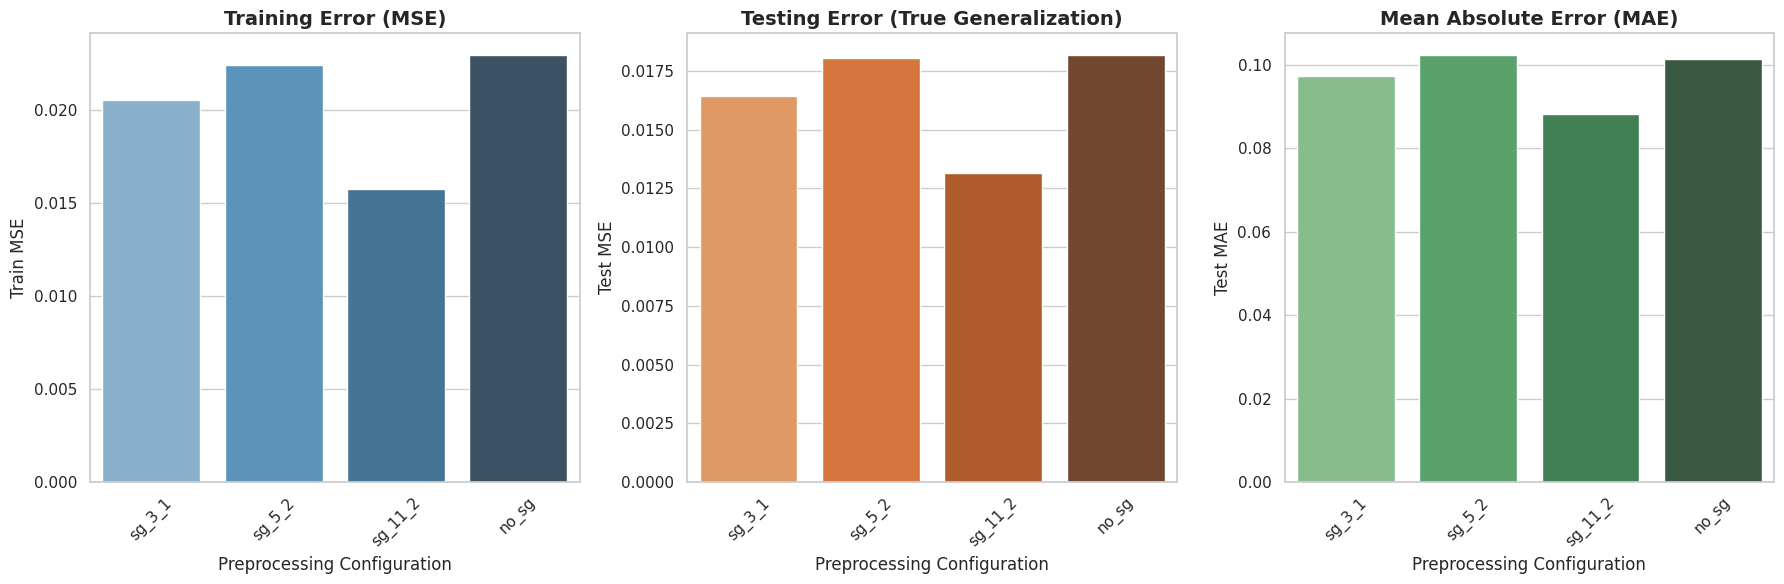

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the results generated by Phase 1
file_name = "phase1_preprocessing_results.csv"
try:
    df = pd.read_csv(file_name)
except FileNotFoundError:
    print(f" Error: '{file_name}' not found. Make sure train_baseline.py finished successfully.")
    exit()

# 2. Set up the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 3. Plot Training Error
sns.barplot(
    data=df, 
    x='preprocessing', 
    y='train_mse', 
    palette='Blues_d', 
    ax=axes[0]
)
axes[0].set_title('Training Error (MSE)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Preprocessing Configuration', fontsize=12)
axes[0].set_ylabel('Train MSE', fontsize=12)

# 4. Plot Testing Error
sns.barplot(
    data=df, 
    x='preprocessing', 
    y='test_mse', 
    palette='Oranges_d', 
    ax=axes[1]
)
axes[1].set_title('Testing Error (True Generalization)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Preprocessing Configuration', fontsize=12)
axes[1].set_ylabel('Test MSE', fontsize=12)

# 5. Plot Mean Absolute Error
sns.barplot(
    data=df, 
    x='preprocessing', 
    y='mae', 
    palette='Greens_d', 
    ax=axes[2]
)
axes[2].set_title('Mean Absolute Error (MAE)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Preprocessing Configuration', fontsize=12)
axes[2].set_ylabel('Test MAE', fontsize=12)
for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("phase1_results_plot.png", dpi=300, bbox_inches='tight')
print("Plot saved as 'phase1_results_plot.png'")
plt.show()

In [17]:
import os
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error

from dataset import create_sequences

print("Initializing GRU Pipeline on CPU...")
# GRU MODEL ARCHITECTURE
class GRUModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out)



# EXPERIMENT HYPERPARAMETERS
DATA_ROOT = "data/processed"
SEQ_LENGTH = 30
EPOCHS = 10
BATCH_SIZE = 64
LEARNING_RATE = 0.001

PREPROCESSING_CONFIGS = [
    "sg_3_1",
    "sg_5_2",
    "sg_11_2",
    "no_sg"
]

# MAIN TRAINING LOOP
if __name__ == "__main__":
    results = []

    for prep in PREPROCESSING_CONFIGS:
        data_path = os.path.join(DATA_ROOT, prep)

        if not os.path.exists(data_path):
            print(f" Skipping {prep} (Directory not found)")
            continue

        print(f"\n Evaluating GRU on Preprocessing Configuration: {prep}")

        all_train_mse = []
        all_test_mse = []
        all_mae = []

        for file in os.listdir(data_path):
            if not file.endswith(".csv"):
                continue

            # 1. Load Data
            df = pd.read_csv(os.path.join(data_path, file))
            data = df[['Smooth_Close', 'Return', 'MA_10', 'EMA_10']].values

            # 2. Sequence Generation
            X, y = create_sequences(data, SEQ_LENGTH)

            if len(X) < 50:
                continue

            # 3. Train/Test Split
            split = int(0.8 * len(X))
            X_train, X_test = X[:split], X[split:]
            y_train, y_test = y[:split], y[split:]

            # 4. Standard Tensor Conversion
            X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
            y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
            X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
            y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

            # 5. Mini-Batch DataLoader Setup
            train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
            train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False) 

            # 6. Model Initialization
            model = GRUModel(input_size=4)
            optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
            loss_fn = nn.MSELoss()

            # 7. Training Phase
            for epoch in range(EPOCHS):
                model.train()
                for batch_X, batch_y in train_loader:
                    pred = model(batch_X)
                    loss = loss_fn(pred, batch_y)

                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()

            # 8. Evaluation Phase
            model.eval()
            with torch.no_grad():
                train_pred = model(X_train_tensor).numpy()
                test_pred = model(X_test_tensor).numpy()

            y_train_np = y_train_tensor.numpy()
            y_test_np = y_test_tensor.numpy()

            train_mse = mean_squared_error(y_train_np, train_pred)
            test_mse = mean_squared_error(y_test_np, test_pred)
            mae = mean_absolute_error(y_test_np, test_pred)

            all_train_mse.append(train_mse)
            all_test_mse.append(test_mse)
            all_mae.append(mae)

        if len(all_test_mse) == 0:
            continue

        # 9. Aggregate Portfolio Metrics
        avg_train = np.mean(all_train_mse)
        avg_test = np.mean(all_test_mse)
        avg_mae = np.mean(all_mae)

        print(f"   Train MSE : {avg_train:.6f}")
        print(f"   Test MSE  : {avg_test:.6f}")
        print(f"   MAE       : {avg_mae:.6f}")

        results.append({
            "preprocessing": prep,
            "train_mse": avg_train,
            "test_mse": avg_test,
            "mae": avg_mae
        })

    
    # SAVE PIPELINE RESULTS
    df_results = pd.DataFrame(results)
    df_results.to_csv("phase1_gru_results.csv", index=False)

    print("\n GRU Pipeline Execution Completed Successfully!")

Initializing GRU Pipeline on CPU...

 Evaluating GRU on Preprocessing Configuration: sg_3_1
   Train MSE : 0.016834
   Test MSE  : 0.013622
   MAE       : 0.088621

 Evaluating GRU on Preprocessing Configuration: sg_5_2
   Train MSE : 0.018868
   Test MSE  : 0.015093
   MAE       : 0.093408

 Evaluating GRU on Preprocessing Configuration: sg_11_2
   Train MSE : 0.011302
   Test MSE  : 0.009516
   MAE       : 0.074581

 Evaluating GRU on Preprocessing Configuration: no_sg
   Train MSE : 0.022946
   Test MSE  : 0.018167
   MAE       : 0.101334

 GRU Pipeline Execution Completed Successfully!


Plot saved as 'phase1_gru_results_plot.png'


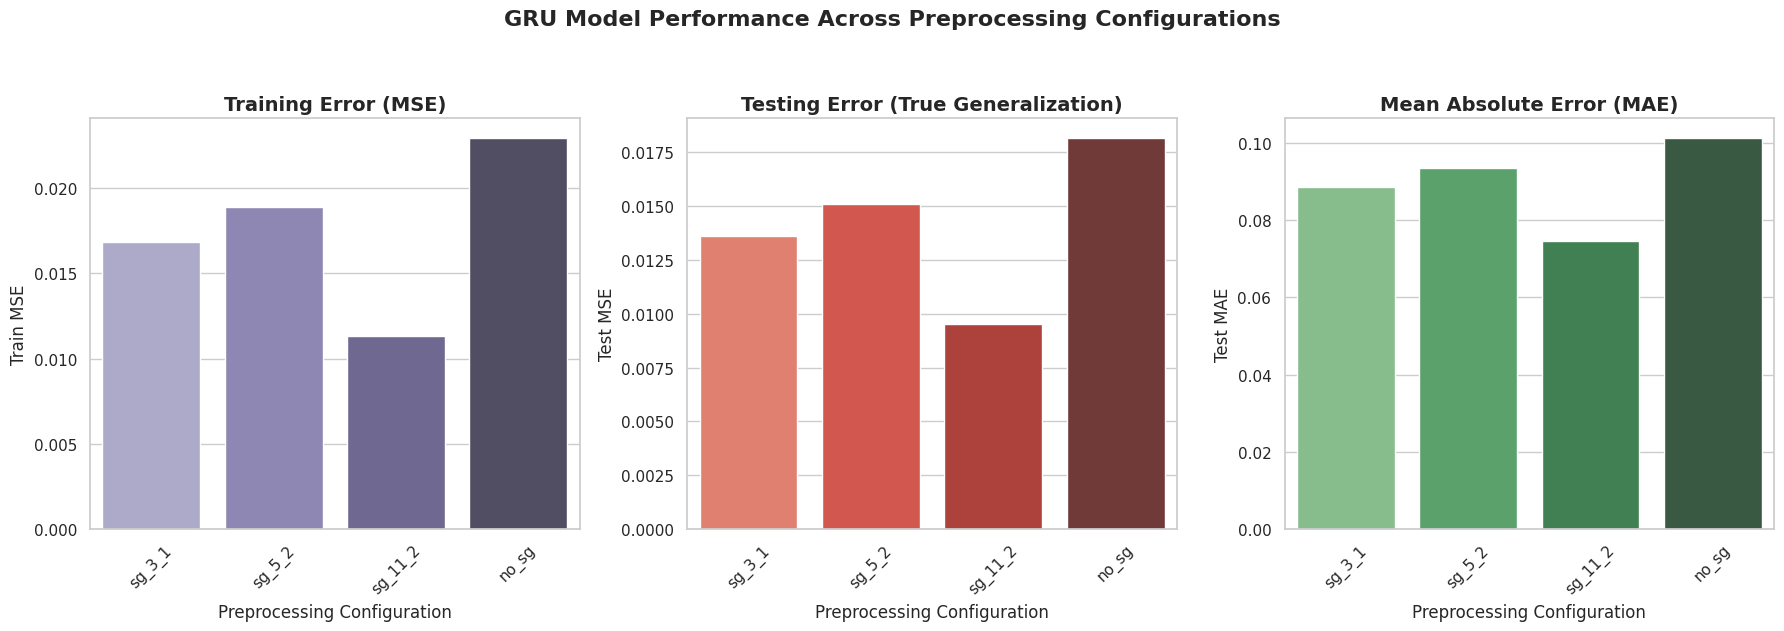

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the results generated by the GRU training script
file_name = "phase1_gru_results.csv"
try:
    df = pd.read_csv(file_name)
except FileNotFoundError:
    print(f" Error: '{file_name}' not found. Make sure train_gru.py finished successfully.")
    exit()

# 2. Set up the visual style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('GRU Model Performance Across Preprocessing Configurations', fontsize=16, fontweight='bold', y=1.05)

# 3. Plot Training Error
sns.barplot(
    data=df, 
    x='preprocessing', 
    y='train_mse', 
    hue='preprocessing', 
    legend=False,       
    palette='Purples_d', 
    ax=axes[0]
)
axes[0].set_title('Training Error (MSE)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Preprocessing Configuration', fontsize=12)
axes[0].set_ylabel('Train MSE', fontsize=12)

# 4. Plot Testing Error 
sns.barplot(
    data=df, 
    x='preprocessing', 
    y='test_mse', 
    hue='preprocessing',
    legend=False,
    palette='Reds_d', 
    ax=axes[1]
)
axes[1].set_title('Testing Error (True Generalization)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Preprocessing Configuration', fontsize=12)
axes[1].set_ylabel('Test MSE', fontsize=12)

# 5. Plot Mean Absolute Error 
sns.barplot(
    data=df, 
    x='preprocessing', 
    y='mae', 
    hue='preprocessing',
    legend=False,
    palette='Greens_d',   
    ax=axes[2]
)
axes[2].set_title('Mean Absolute Error (MAE)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Preprocessing Configuration', fontsize=12)
axes[2].set_ylabel('Test MAE', fontsize=12)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
save_file = "phase1_gru_results_plot.png"
plt.savefig(save_file, dpi=300, bbox_inches='tight')
print(f"Plot saved as '{save_file}'")
plt.show()

In [19]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error
import copy

from dataset import create_sequences

print("Initializing SSA Tuning on CPU...")


# DYNAMIC LSTM MODEL
class DynamicLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

# FITNESS FUNCTION 
def evaluate_fitness(params, X_train, y_train, X_val, y_val):
    """
    Decodes the sparrow's position into hyperparameters, trains the LSTM, 
    and returns the Validation MSE as the fitness score.
    """
    lr = params[0]
    hidden_size = int(round(params[1]))
    num_layers = int(round(params[2]))
    batch_size = int(round(params[3]))

    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

    model = DynamicLSTM(input_size=4, hidden_size=hidden_size, num_layers=num_layers)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    model.train()
    for epoch in range(5):  # Keep this low for tuning speed
        for batch_X, batch_y in train_loader:
            pred = model(batch_X)
            loss = loss_fn(pred, batch_y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val).numpy()
        val_mse = mean_squared_error(y_val.numpy(), val_pred)
    
    return val_mse


# THE SPARROW SEARCH ALGORITHM
def run_ssa(X_train, y_train, X_val, y_val, bounds, pop_size=10, max_iter=15):
    dim = len(bounds)
    lb = np.array([b[0] for b in bounds])
    ub = np.array([b[1] for b in bounds])

    PD = 0.2  
    SD = 0.1  
    ST = 0.8  
    
    p_num = int(pop_size * PD)
    s_num = int(pop_size * SD)

    X = np.random.uniform(lb, ub, (pop_size, dim))
    fitness = np.zeros(pop_size)

    print("\nInitializing Swarm Fitness (This will take a moment)...")
    for i in range(pop_size):
        fitness[i] = evaluate_fitness(X[i], X_train, y_train, X_val, y_val)

    best_fitness = np.min(fitness)
    best_pos = X[np.argmin(fitness)].copy()

    for t in range(max_iter):
        sort_idx = np.argsort(fitness)
        X = X[sort_idx]
        fitness = fitness[sort_idx]
        
        worst_pos = X[-1].copy()
        best_pos_current = X[0].copy()

        # Update Producers
        R2 = np.random.rand()
        for i in range(p_num):
            if R2 < ST:
                X[i] = X[i] * np.exp(-i / (np.random.rand() * max_iter))
            else:
                X[i] = X[i] + np.random.randn() * np.ones(dim)

        # Update Scroungers
        for i in range(p_num, pop_size):
            if i > pop_size / 2:
                X[i] = np.random.randn() * np.exp((worst_pos - X[i]) / (i ** 2))
            else:
               
                A = np.random.choice([-1, 1], size=(1, dim))
                A_plus = A.T @ np.linalg.pinv(A @ A.T)
                # Flatten the result back to 1D to match the hyperparameter array
                X[i] = best_pos_current + np.abs(X[i] - best_pos_current) * A_plus.flatten()

        # Update Scouts
        scout_idx = np.random.choice(range(pop_size), s_num, replace=False)
        for i in scout_idx:
            if fitness[i] > best_fitness:
                X[i] = best_pos + np.random.randn() * np.abs(X[i] - best_pos)
            else:
                K = np.random.uniform(-1, 1)
                X[i] = X[i] + K * (np.abs(X[i] - worst_pos) / (fitness[i] - fitness[-1] + 1e-8))

        for i in range(pop_size):
            X[i] = np.clip(X[i], lb, ub)
            fitness[i] = evaluate_fitness(X[i], X_train, y_train, X_val, y_val)

        if np.min(fitness) < best_fitness:
            best_fitness = np.min(fitness)
            best_pos = X[np.argmin(fitness)].copy()

        print(f"Iteration {t+1}/{max_iter} | Best MSE: {best_fitness:.6f} | Params: LR={best_pos[0]:.4f}, Hidden={int(round(best_pos[1]))}, Layers={int(round(best_pos[2]))}, Batch={int(round(best_pos[3]))}")

    return best_pos, best_fitness


# MAIN EXECUTION
if __name__ == "__main__":
    BEST_PREP = "sg_11_2" 
    DATA_PATH = os.path.join("data/processed", BEST_PREP)
    
    PROXY_FILE = "RELIANCE.NS.csv" 
    file_path = os.path.join(DATA_PATH, PROXY_FILE)
    
    if not os.path.exists(file_path):
        print(f" Could not find proxy file at {file_path}.")
        exit()

    print(f" Loading Proxy Data for Tuning: {PROXY_FILE}")
    df = pd.read_csv(file_path)
    data = df[['Smooth_Close', 'Return', 'MA_10', 'EMA_10']].values
    
    X, y = create_sequences(data, seq_length=30)
    split = int(0.8 * len(X))
    X_train, X_val = X[:split], X[split:]
    y_train, y_val = y[:split], y[split:]

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    bounds = [
        [0.0001, 0.01],  # LR
        [16, 128],       # Hidden Size
        [1, 3],          # Num Layers
        [16, 128]        # Batch Size
    ]

    print("\n Starting Sparrow Search Algorithm (SSA)...")
    best_params, best_mse = run_ssa(
        X_train_t, y_train_t, X_val_t, y_val_t, 
        bounds=bounds, 
        pop_size=10,   
        max_iter=10    
    )
    print(" SSA TUNING COMPLETE")
    print(f"Minimum Validation MSE: {best_mse:.6f}")
    print("Optimal Hyperparameters Found:")
    print(f" - Learning Rate : {best_params[0]:.5f}")
    print(f" - Hidden Size   : {int(round(best_params[1]))}")
    print(f" - Num Layers    : {int(round(best_params[2]))}")
    print(f" - Batch Size    : {int(round(best_params[3]))}")

Initializing SSA Tuning on CPU...
 Loading Proxy Data for Tuning: RELIANCE.NS.csv

 Starting Sparrow Search Algorithm (SSA)...

Initializing Swarm Fitness (This will take a moment)...
Iteration 1/10 | Best MSE: 0.004424 | Params: LR=0.0100, Hidden=16, Layers=1, Batch=16
Iteration 2/10 | Best MSE: 0.004354 | Params: LR=0.0081, Hidden=16, Layers=1, Batch=28
Iteration 3/10 | Best MSE: 0.004072 | Params: LR=0.0090, Hidden=16, Layers=1, Batch=16
Iteration 4/10 | Best MSE: 0.003815 | Params: LR=0.0093, Hidden=16, Layers=1, Batch=16
Iteration 5/10 | Best MSE: 0.003815 | Params: LR=0.0093, Hidden=16, Layers=1, Batch=16
Iteration 6/10 | Best MSE: 0.003815 | Params: LR=0.0093, Hidden=16, Layers=1, Batch=16
Iteration 7/10 | Best MSE: 0.003815 | Params: LR=0.0093, Hidden=16, Layers=1, Batch=16
Iteration 8/10 | Best MSE: 0.003815 | Params: LR=0.0093, Hidden=16, Layers=1, Batch=16
Iteration 9/10 | Best MSE: 0.003815 | Params: LR=0.0093, Hidden=16, Layers=1, Batch=16
Iteration 10/10 | Best MSE: 0.003

In [20]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error

from dataset import create_sequences

print("Initializing GRU SSA Tuning on CPU...")

# DYNAMIC GRU MODEL
class DynamicGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out)

def evaluate_fitness(params, X_train, y_train, X_val, y_val):
    lr = params[0]
    hidden_size = int(round(params[1]))
    num_layers = int(round(params[2]))
    batch_size = int(round(params[3]))

    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

    model = DynamicGRU(input_size=4, hidden_size=hidden_size, num_layers=num_layers)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    model.train()
    for epoch in range(5):  
        for batch_X, batch_y in train_loader:
            pred = model(batch_X)
            loss = loss_fn(pred, batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val).numpy()
        val_mse = mean_squared_error(y_val.numpy(), val_pred)
    return val_mse

def run_ssa(X_train, y_train, X_val, y_val, bounds, pop_size=10, max_iter=15):
    dim = len(bounds)
    lb = np.array([b[0] for b in bounds])
    ub = np.array([b[1] for b in bounds])

    PD, SD, ST = 0.2, 0.1, 0.8  
    p_num = int(pop_size * PD)
    s_num = int(pop_size * SD)

    X = np.random.uniform(lb, ub, (pop_size, dim))
    fitness = np.zeros(pop_size)

    print("\nInitializing Swarm Fitness...")
    for i in range(pop_size):
        fitness[i] = evaluate_fitness(X[i], X_train, y_train, X_val, y_val)

    best_fitness = np.min(fitness)
    best_pos = X[np.argmin(fitness)].copy()

    for t in range(max_iter):
        sort_idx = np.argsort(fitness)
        X = X[sort_idx]
        fitness = fitness[sort_idx]
        worst_pos = X[-1].copy()
        best_pos_current = X[0].copy()

        for i in range(p_num):
            if np.random.rand() < ST:
                X[i] = X[i] * np.exp(-i / (np.random.rand() * max_iter))
            else:
                X[i] = X[i] + np.random.randn() * np.ones(dim)

        for i in range(p_num, pop_size):
            if i > pop_size / 2:
                X[i] = np.random.randn() * np.exp((worst_pos - X[i]) / (i ** 2))
            else:
                A = np.random.choice([-1, 1], size=(1, dim))
                A_plus = A.T @ np.linalg.pinv(A @ A.T)
                X[i] = best_pos_current + np.abs(X[i] - best_pos_current) * A_plus.flatten()

        scout_idx = np.random.choice(range(pop_size), s_num, replace=False)
        for i in scout_idx:
            if fitness[i] > best_fitness:
                X[i] = best_pos + np.random.randn() * np.abs(X[i] - best_pos)
            else:
                K = np.random.uniform(-1, 1)
                X[i] = X[i] + K * (np.abs(X[i] - worst_pos) / (fitness[i] - fitness[-1] + 1e-8))

        for i in range(pop_size):
            X[i] = np.clip(X[i], lb, ub)
            fitness[i] = evaluate_fitness(X[i], X_train, y_train, X_val, y_val)

        if np.min(fitness) < best_fitness:
            best_fitness = np.min(fitness)
            best_pos = X[np.argmin(fitness)].copy()

        print(f"Iteration {t+1}/{max_iter} | Best MSE: {best_fitness:.6f}")

    return best_pos, best_fitness

if __name__ == "__main__":
    BEST_PREP = "sg_11_2" 
    DATA_PATH = os.path.join("data/processed", BEST_PREP)
    file_path = os.path.join(DATA_PATH, "RELIANCE.NS.csv")
    
    df = pd.read_csv(file_path)
    data = df[['Smooth_Close', 'Return', 'MA_10', 'EMA_10']].values
    
    X, y = create_sequences(data, seq_length=30)
    split = int(0.8 * len(X))
    X_train_t = torch.tensor(X[:split], dtype=torch.float32)
    y_train_t = torch.tensor(y[:split], dtype=torch.float32).view(-1, 1)
    X_val_t = torch.tensor(X[split:], dtype=torch.float32)
    y_val_t = torch.tensor(y[split:], dtype=torch.float32).view(-1, 1)

    bounds = [[0.0001, 0.01], [16, 128], [1, 3], [16, 128]]

    best_params, _ = run_ssa(X_train_t, y_train_t, X_val_t, y_val_t, bounds=bounds, pop_size=10, max_iter=10)
    print("\n GRU OPTIMAL PARAMS ")
    print(f"LR: {best_params[0]:.5f}, Hidden: {int(round(best_params[1]))}, Layers: {int(round(best_params[2]))}, Batch: {int(round(best_params[3]))}")

Initializing GRU SSA Tuning on CPU...

Initializing Swarm Fitness...
Iteration 1/10 | Best MSE: 0.003818
Iteration 2/10 | Best MSE: 0.003818
Iteration 3/10 | Best MSE: 0.003813
Iteration 4/10 | Best MSE: 0.003813
Iteration 5/10 | Best MSE: 0.003813
Iteration 6/10 | Best MSE: 0.003813
Iteration 7/10 | Best MSE: 0.003806
Iteration 8/10 | Best MSE: 0.003806
Iteration 9/10 | Best MSE: 0.003806
Iteration 10/10 | Best MSE: 0.003806

 GRU OPTIMAL PARAMS 
LR: 0.00900, Hidden: 16, Layers: 1, Batch: 16


In [21]:
import os
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error
from dataset import create_sequences

print(" Initializing Final Optimized Pipeline on CPU...")


OPTIMAL_LSTM = {
    "lr": 0.00928,      
    "hidden": 16,     
    "layers": 1,      
    "batch": 16       
}

OPTIMAL_GRU = {
    "lr": 0.00900,      
    "hidden": 16,     
    "layers": 1,      
    "batch": 16       
}


class DynamicLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

class DynamicGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


DATA_ROOT = "data/processed"

PREPROCESSING_CONFIGS = ["sg_11_2"] 

MODELS_TO_TEST = ["LSTM", "GRU"]
EPOCHS = 15

if __name__ == "__main__":
    results = []

    for prep in PREPROCESSING_CONFIGS:
        data_path = os.path.join(DATA_ROOT, prep)
        if not os.path.exists(data_path): 
            print(f" Error: Could not find folder {data_path}")
            continue

        for model_name in MODELS_TO_TEST:
            print(f"\n Evaluating Optimized {model_name} on {prep}")
            
            cfg = OPTIMAL_LSTM if model_name == "LSTM" else OPTIMAL_GRU
            
            all_train_mse, all_test_mse, all_mae = [], [], []

            for file in os.listdir(data_path):
                if not file.endswith(".csv"): continue

                df = pd.read_csv(os.path.join(data_path, file))
                data = df[['Smooth_Close', 'Return', 'MA_10', 'EMA_10']].values
                X, y = create_sequences(data, 30)
                if len(X) < 50: continue

                split = int(0.8 * len(X))
                X_train_t = torch.tensor(X[:split], dtype=torch.float32)
                y_train_t = torch.tensor(y[:split], dtype=torch.float32).view(-1, 1)
                X_test_t = torch.tensor(X[split:], dtype=torch.float32)
                y_test_t = torch.tensor(y[split:], dtype=torch.float32).view(-1, 1)

                train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=cfg["batch"], shuffle=False)

                if model_name == "LSTM":
                    model = DynamicLSTM(4, cfg["hidden"], cfg["layers"])
                else:
                    model = DynamicGRU(4, cfg["hidden"], cfg["layers"])

                optimizer = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
                loss_fn = nn.MSELoss()

                model.train()
                for epoch in range(EPOCHS):
                    for batch_X, batch_y in train_loader:
                        pred = model(batch_X)
                        loss = loss_fn(pred, batch_y)
                        optimizer.zero_grad()
                        loss.backward()
                        optimizer.step()

                model.eval()
                with torch.no_grad():
                    train_pred = model(X_train_t).numpy()
                    test_pred = model(X_test_t).numpy()

                all_train_mse.append(mean_squared_error(y_train_t.numpy(), train_pred))
                all_test_mse.append(mean_squared_error(y_test_t.numpy(), test_pred))
                all_mae.append(mean_absolute_error(y_test_t.numpy(), test_pred))

            if len(all_test_mse) > 0:
                results.append({
                    "model": model_name,
                    "preprocessing": prep,
                    "train_mse": np.mean(all_train_mse),
                    "test_mse": np.mean(all_test_mse),
                    "mae": np.mean(all_mae)
                })

    df_results = pd.DataFrame(results)
    df_results.to_csv("final_optimized_results.csv", index=False)
    print("\n Final Optimized Evaluation Completed!")

 Initializing Final Optimized Pipeline on CPU...

 Evaluating Optimized LSTM on sg_11_2

 Evaluating Optimized GRU on sg_11_2

 Final Optimized Evaluation Completed!


 Plot saved as 'final_optimized_comparison.png'


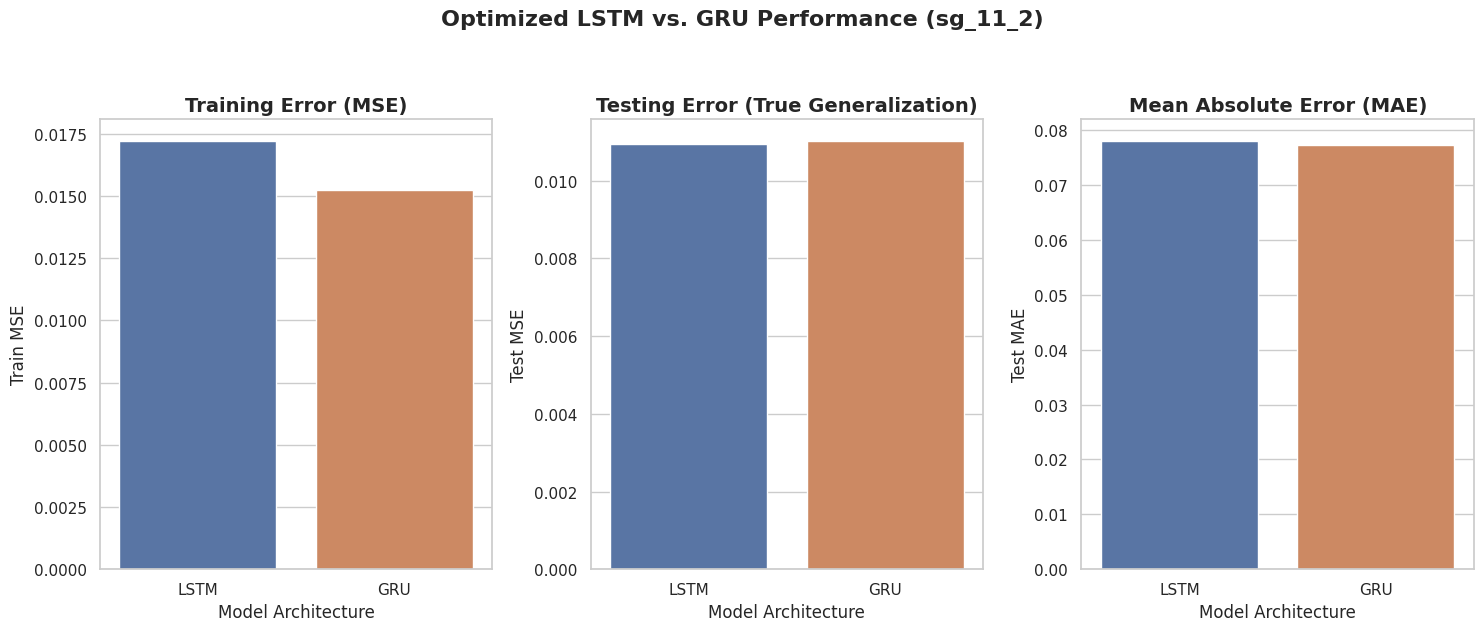

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df = pd.read_csv("final_optimized_results.csv")
except FileNotFoundError:
    print(" Error: 'final_optimized_results.csv' not found. Make sure the evaluation script finished.")
    exit()

sns.set_theme(style="whitegrid")


fig, axes = plt.subplots(1, 3, figsize=(15, 6))


fig.suptitle('Optimized LSTM vs. GRU Performance (sg_11_2)', fontsize=16, fontweight='bold', y=1.05)

custom_palette = ['#4C72B0', '#DD8452']

# 1. Train MSE
sns.barplot(
    data=df, x='model', y='train_mse', 
    hue='model', legend=False, palette=custom_palette, ax=axes[0]
)
axes[0].set_title('Training Error (MSE)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Train MSE', fontsize=12)
axes[0].set_xlabel('Model Architecture', fontsize=12)

# 2. Test MSE 
sns.barplot(
    data=df, x='model', y='test_mse', 
    hue='model', legend=False, palette=custom_palette, ax=axes[1]
)
axes[1].set_title('Testing Error (True Generalization)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Test MSE', fontsize=12)
axes[1].set_xlabel('Model Architecture', fontsize=12)

# 3. MAE
sns.barplot(
    data=df, x='model', y='mae', 
    hue='model', legend=False, palette=custom_palette, ax=axes[2]
)
axes[2].set_title('Mean Absolute Error (MAE)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Test MAE', fontsize=12)
axes[2].set_xlabel('Model Architecture', fontsize=12)


plt.tight_layout()
plt.savefig("final_optimized_comparison.png", dpi=300, bbox_inches='tight')
print(" Plot saved as 'final_optimized_comparison.png'")
plt.show()

In [23]:
import os
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error

BEST_PREP = "sg_11_2" 
DATA_ROOT = f"data/processed/{BEST_PREP}"

OPTIMAL_CFG = {
    "lr": 0.001,      
    "hidden": 64,     
    "layers": 1,      
    "batch": 64       
}

SEQ_LENGTH = 30
EPOCHS = 10 

print(" Initializing Live Portfolio Screener...")

class DynamicGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

def create_sequences(data, seq_length=30):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][1]) 
    return np.array(X), np.array(y)


# SCREENING ENGINE
if __name__ == "__main__":
    screener_results = []

    for file in os.listdir(DATA_ROOT):
        if not file.endswith(".csv"): continue
            
        ticker = file.replace(".csv", "")
        print(f"Analyzing {ticker}...")

        file_path = os.path.join(DATA_ROOT, file)
        df = pd.read_csv(file_path)
        data = df[['Smooth_Close', 'Return', 'MA_10', 'EMA_10']].values

        X, y = create_sequences(data, SEQ_LENGTH)
        if len(X) < 50: continue

        split = int(0.8 * len(X))
        X_train_t = torch.tensor(X[:split], dtype=torch.float32)
        y_train_t = torch.tensor(y[:split], dtype=torch.float32).view(-1, 1)
        X_test_t = torch.tensor(X[split:], dtype=torch.float32)
        y_test_t = torch.tensor(y[split:], dtype=torch.float32).view(-1, 1)

        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=OPTIMAL_CFG["batch"], shuffle=False)

        model = DynamicGRU(4, OPTIMAL_CFG["hidden"], OPTIMAL_CFG["layers"])
        optimizer = torch.optim.Adam(model.parameters(), lr=OPTIMAL_CFG["lr"])
        loss_fn = nn.MSELoss()

        model.train()
        for epoch in range(EPOCHS):
            for batch_X, batch_y in train_loader:
                pred = model(batch_X)
                loss = loss_fn(pred, batch_y)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            test_pred = model(X_test_t).numpy()
            y_test_np = y_test_t.numpy()
            stock_test_mse = mean_squared_error(y_test_np, test_pred)
            
            # Measures what percentage of the time the model correctly guessed the direction (Up/Down)
            directional_accuracy = np.mean((test_pred > 0) == (y_test_np > 0))

        latest_sequence = data[-SEQ_LENGTH:]
        latest_tensor = torch.tensor(latest_sequence, dtype=torch.float32).unsqueeze(0)
        
        with torch.no_grad():
            predicted_next_return = model(latest_tensor).item()

        # Sum of the actual returns over the last 5 trading days
        recent_trend = np.sum(data[-5:, 1]) 

        screener_results.append({
            "stock": ticker,
            "pred_return": predicted_next_return,
            "mse": stock_test_mse,
            "accuracy": directional_accuracy,
            "trend": recent_trend
        })

    if not screener_results:
        exit()

    df_screen = pd.DataFrame(screener_results)
    df_screen.to_csv("stock_prediction_summary.csv", index=False)
    print("\n Full screening report saved to 'stock_prediction_summary.csv'")

 Initializing Live Portfolio Screener...
Analyzing KOTAKBANK.NS...
Analyzing MARUTI.NS...
Analyzing JSWSTEEL.NS...
Analyzing ASIANPAINT.NS...
Analyzing DABUR.NS...
Analyzing M&M.NS...
Analyzing ITC.NS...
Analyzing AXISBANK.NS...
Analyzing SBIN.NS...
Analyzing COALINDIA.NS...
Analyzing PIDILITIND.NS...
Analyzing EICHERMOT.NS...
Analyzing ULTRACEMCO.NS...
Analyzing ICICIBANK.NS...
Analyzing HEROMOTOCO.NS...
Analyzing CIPLA.NS...
Analyzing INDUSINDBK.NS...
Analyzing POWERGRID.NS...
Analyzing TECHM.NS...
Analyzing BAJAJ-AUTO.NS...
Analyzing BRITANNIA.NS...
Analyzing NESTLEIND.NS...
Analyzing ICICIPRULI.NS...
Analyzing LT.NS...
Analyzing DIVISLAB.NS...
Analyzing GRASIM.NS...
Analyzing INFY.NS...
Analyzing UPL.NS...
Analyzing HDFCLIFE.NS...
Analyzing WIPRO.NS...
Analyzing BAJFINANCE.NS...
Analyzing BAJAJFINSV.NS...
Analyzing HCLTECH.NS...
Analyzing TITAN.NS...
Analyzing TATASTEEL.NS...
Analyzing ADANIENT.NS...
Analyzing ADANIPORTS.NS...
Analyzing SBILIFE.NS...
Analyzing TCS.NS...
Analyzing H

In [24]:
import os
import pandas as pd
import numpy as np

INPUT_FILE = "stock_prediction_summary.csv"
OUTPUT_DIR = "screening_results"

# Generates Top 5, Top 10, and Top 15 lists
K_VALUES = [5, 10, 15]

# Professional Heuristic Quant Weights
W_RETURN = 0.40   # 40% Weight: High predicted return
W_ACCURACY = 0.30 # 30% Weight: Model has a high historical Hit Rate for this stock
W_TREND = 0.20    # 20% Weight: Stock has strong recent 5-day momentum
W_ERROR = 0.10    # 10% Penalty: Model has a high absolute error (MSE) for this stock



# HELPERS
def robust_normalize(series: pd.Series) -> pd.Series:
    """
    Normalizes data between 0 and 1, but clips extreme outliers 
    (bottom 5% and top 5%) to prevent them from breaking the distribution.
    """
    lower = series.quantile(0.05)
    upper = series.quantile(0.95)
    clipped = series.clip(lower, upper)
    
    denom = clipped.max() - clipped.min()
    if denom == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (clipped - clipped.min()) / denom


def prepare_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    required_cols = ["stock", "pred_return", "mse", "accuracy", "trend"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f" Missing columns in input file: {missing}. Make sure to run portfolio_screener.py first!")

    # Robust Normalization
    df["norm_return"] = robust_normalize(df["pred_return"])
    df["norm_accuracy"] = robust_normalize(df["accuracy"])
    df["norm_trend"] = robust_normalize(df["trend"])
    df["norm_mse"] = robust_normalize(df["mse"])

    return df


def score_equal_weights(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["score_equal"] = (
        df["norm_return"] +
        df["norm_accuracy"] +
        df["norm_trend"] +
        (1 - df["norm_mse"])
    ) / 4.0

    df = df.sort_values("score_equal", ascending=False).reset_index(drop=True)
    return df


def score_heuristic_weights(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Return is prioritized, momentum/accuracy add confidence, error reduces the score
    df["score_heuristic"] = (
        W_RETURN * df["norm_return"] +
        W_ACCURACY * df["norm_accuracy"] +
        W_TREND * df["norm_trend"] -
        W_ERROR * df["norm_mse"]
    )

    df = df.sort_values("score_heuristic", ascending=False).reset_index(drop=True)
    return df


def save_top_k(df_ranked: pd.DataFrame, k: int, method_name: str):
    topk = df_ranked.head(k).copy()
    out_path = os.path.join(OUTPUT_DIR, f"{method_name}_top_{k}.csv")
    topk.to_csv(out_path, index=False)
    print(f" Saved: {out_path}")
    print(topk[["stock", f"score_{method_name}", "pred_return", "accuracy", "trend", "mse"]].to_string(index=False))
    print("-" * 75)



# MAIN
def main():
    print("Initializing Final Portfolio Ranking Engine...")
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    try:
        df = pd.read_csv(INPUT_FILE)
    except FileNotFoundError:
        print(f" Error: '{INPUT_FILE}' not found. Please run portfolio_screener.py to generate it.")
        return

    df = prepare_features(df)

    # Apply Ranking Algorithms
    eq_ranked = score_equal_weights(df)
    eq_ranked.to_csv(os.path.join(OUTPUT_DIR, "ranked_equal_weights.csv"), index=False)

    h_ranked = score_heuristic_weights(df)
    h_ranked.to_csv(os.path.join(OUTPUT_DIR, "ranked_heuristic_weights.csv"), index=False)

    print("  EQUAL WEIGHTS RANKING (Balanced Portfolio)")
    for k in K_VALUES:
        save_top_k(eq_ranked, k, "equal")

    print(" HEURISTIC WEIGHTS RANKING (Aggressive Portfolio)")
    for k in K_VALUES:
        save_top_k(h_ranked, k, "heuristic")
        
    print("\n Full Pipeline Execution Complete! Check the /screening_results folder.")


if __name__ == "__main__":
    main()

Initializing Final Portfolio Ranking Engine...
  EQUAL WEIGHTS RANKING (Balanced Portfolio)
 Saved: screening_results/equal_top_5.csv
        stock  score_equal  pred_return  accuracy    trend      mse
HEROMOTOCO.NS     0.938830     0.798580       1.0 4.099310 0.007794
       M&M.NS     0.860724     0.706524       1.0 3.396648 0.007297
 BRITANNIA.NS     0.854882     0.626838       1.0 3.824800 0.007406
     DABUR.NS     0.850681     0.710198       1.0 3.345985 0.007490
     WIPRO.NS     0.830263     0.736431       1.0 4.051721 0.011619
---------------------------------------------------------------------------
 Saved: screening_results/equal_top_10.csv
        stock  score_equal  pred_return  accuracy    trend      mse
HEROMOTOCO.NS     0.938830     0.798580       1.0 4.099310 0.007794
       M&M.NS     0.860724     0.706524       1.0 3.396648 0.007297
 BRITANNIA.NS     0.854882     0.626838       1.0 3.824800 0.007406
     DABUR.NS     0.850681     0.710198       1.0 3.345985 0.007490

In [25]:
import os
import numpy as np
import pandas as pd
import cvxpy as cp

print("Initializing Institutional mCVaR Portfolio Optimizer...")

# 1. CONFIGURATION
RAW_DATA_DIR = "data/raw"           
SCREENING_DIR = "screening_results"  
OUTPUT_DIR = "mcvar_results"       

# Pipeline dimensions
METHODS = ["equal", "heuristic"]
K_VALUES = [5, 10, 15]

# Risk & Allocation Parameters
CONFIDENCE_LEVELS = [0.90, 0.95, 0.99]
RETURN_FREQUENCY = "D"                
MIN_ENTROPY_FRACTION = 0.5             
TARGET_RETURN_MULTIPLIER = 0.8         # Target 80% of the GRU's predicted return
EPS = 1e-12                            # Small epsilon to prevent division by zero


# 2. DATA LOADING
def load_return_series(stock_name: str, freq: str = "D") -> pd.DataFrame:
    path = os.path.join(RAW_DATA_DIR, f"{stock_name}.csv")
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing raw file for {stock_name}")

    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lower()
    
    if 'close' not in df.columns:
        raise ValueError(f"Missing 'Close' column. Found: {list(df.columns)}")

    if df['close'].dtype == object:
        df['close'] = df['close'].astype(str).str.replace(',', '', regex=False)
    # Convert to float numbers. Anything broken becomes NaN.
    df['close'] = pd.to_numeric(df['close'], errors='coerce')

    date_col = None
    for col in ['date', 'timestamp', 'time', 'day']:
        if col in df.columns:
            date_col = col
            break

    if date_col:
        # Standard chronological alignment using Dates
        df["Date"] = pd.to_datetime(df[date_col], errors='coerce')
        df = df.sort_values("Date").dropna(subset=["close"]).copy()
        df = df.set_index("Date")
    else:
    
        df = df.dropna(subset=["close"]).copy()
        df = df.reset_index(drop=True)

    # Calculate returns
    if freq.upper() == "M" and date_col:
        df = df[["close"]].resample("M").last().dropna()
        returns = df["close"].pct_change().dropna()
    else:
        # If no dates exist, we fall back to row-by-row (daily) returns
        returns = df["close"].pct_change().dropna()

    return returns.rename(stock_name).to_frame()


def build_return_matrix(selected_df: pd.DataFrame, freq: str = "D"):
    stocks = selected_df["stock"].tolist()
    frames = []
    valid_stocks = []

    
    for stock in stocks:
        try:
            s = load_return_series(stock, freq=freq)
            frames.append(s)
            valid_stocks.append(stock)
        except Exception as e:
            print(f" Skipping {stock} due to raw data issue: {e}")

    if not frames:
        raise ValueError("All stocks failed to load. Check your data/raw/ folder.")

    # Merge valid stocks into a single aligned historical matrix
    merged = pd.concat(frames, axis=1, join="inner").dropna()
    merged = merged[valid_stocks]
    
    pred_mu = (
        selected_df.set_index("stock")
        .loc[valid_stocks, "pred_return"]
        .astype(float)
        .values
    )

    return merged, merged.values, pred_mu



# 3. MATHEMATICAL OPTIMIZATION
def solve_mcvar(R: np.ndarray, mu_pred: np.ndarray, alpha: float = 0.95, target_return: float | None = None, min_entropy_fraction: float | None = 0.5):
    T, n = R.shape
    if T < 10 or n < 2:
        raise ValueError("Not enough historical scenarios to optimize mCVaR.")

    if target_return is None:
        target_return = float(np.mean(mu_pred) * TARGET_RETURN_MULTIPLIER)

   
    base = abs(target_return) if abs(target_return) > EPS else 1e-4
    target_candidates = [
        target_return,
        target_return - 0.1 * base,
        target_return - 0.2 * base,
        target_return - 0.5 * base,
        target_return - 1.0 * base,
    ]

    entropy_max = np.log(n)
    if min_entropy_fraction is not None:
        entropy_candidates = [
            min_entropy_fraction * entropy_max,
            0.50 * min_entropy_fraction * entropy_max,
            None,
        ]
    else:
        entropy_candidates = [None]

    for ent_min in entropy_candidates:
        for tar in target_candidates:
            w = cp.Variable(n)
            tau = cp.Variable()
            u = cp.Variable(T)

            portfolio_return_scenarios = R @ w
            losses = -portfolio_return_scenarios

            # Objective: Minimize Conditional Value at Risk
            cvar = tau + (1.0 / ((1.0 - alpha) * T)) * cp.sum(u)

            constraints = [
                cp.sum(w) == 1,         
                w >= 0,                 
                u >= 0,
                u >= losses - tau,      
                mu_pred @ w >= tar,    
            ]

            if ent_min is not None:
                constraints.append(cp.sum(cp.entr(w)) >= ent_min)

            problem = cp.Problem(cp.Minimize(cvar), constraints)

            try:
                problem.solve(solver=cp.SCS, verbose=False, max_iters=30000)
            except Exception:
                continue

            if problem.status in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE] and w.value is not None:
                weights = np.array(w.value).reshape(-1)
                weights = np.clip(weights, 0, None)
                if weights.sum() > 0:
                    weights = weights / weights.sum() 
                return weights, float(cvar.value), float(tar), ent_min

    raise RuntimeError("mCVaR optimization mathematically failed for all targets.")



# 4. PORTFOLIO EVALUATION METRICS
def evaluate_portfolio(portfolio_returns: np.ndarray, weights: np.ndarray, alpha: float = 0.95):
    mean_ret = float(np.mean(portfolio_returns))
    vol = float(np.std(portfolio_returns, ddof=1) + EPS)

    downside = portfolio_returns[portfolio_returns < 0]
    downside_std = float(np.std(downside, ddof=1) + EPS) if len(downside) > 1 else EPS

    sharpe = mean_ret / vol
    sortino = mean_ret / downside_std

    losses = -portfolio_returns
    var_thr = np.quantile(losses, alpha)
    cvar_emp = float(np.mean(losses[losses >= var_thr])) if np.any(losses >= var_thr) else float(np.mean(losses))

    cum_return = float(np.prod(1.0 + portfolio_returns) - 1.0)
    entropy = float(-np.sum(weights * np.log(weights + EPS)))

    return {
        "mean_return": mean_ret,
        "volatility": vol,
        "sharpe": sharpe,
        "sortino": sortino,
        "empirical_cvar": cvar_emp,
        "cumulative_return": cum_return,
        "entropy": entropy,
    }



# 5. MAIN EXECUTION LOOP
def run():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    summary_rows = []

    for method in METHODS:
        for k in K_VALUES:
            screen_file = os.path.join(SCREENING_DIR, f"{method}_top_{k}.csv")
            if not os.path.exists(screen_file):
                continue

            print(f"\n Optimizing {method.upper()} Portfolio (Top {k} Stocks)...")
            selected = pd.read_csv(screen_file)

            if selected.empty:
                continue

            try:
                merged_df, R, mu_pred = build_return_matrix(selected, freq=RETURN_FREQUENCY)
            except ValueError as e:
                print(e)
                continue
                
            base_target = float(np.mean(mu_pred) * TARGET_RETURN_MULTIPLIER)

            for alpha in CONFIDENCE_LEVELS:
                try:
                    weights, cvar_value, used_target, used_entropy_min = solve_mcvar(
                        R=R, mu_pred=mu_pred, alpha=alpha,
                        target_return=base_target, min_entropy_fraction=MIN_ENTROPY_FRACTION,
                    )
                except Exception as e:
                    print(f" Failed at {int(alpha*100)}% Confidence: {e}")
                    continue

                portfolio_returns = R @ weights

                weights_df = pd.DataFrame({
                    "stock": selected["stock"].tolist()[:len(weights)], 
                    "weight": weights
                }).sort_values("weight", ascending=False)

                weights_df["allocation_%"] = (weights_df["weight"] * 100).round(2)

                weights_path = os.path.join(OUTPUT_DIR, f"weights_{method}_k{k}_alpha{str(alpha).replace('.','')}.csv")
                weights_df.to_csv(weights_path, index=False)

                metrics = evaluate_portfolio(portfolio_returns, weights=weights, alpha=alpha)

                summary_rows.append({
                    "method": method,
                    "k": k,
                    "alpha": alpha,
                    "target_return": used_target,
                    "cvar_optimized": cvar_value,
                    "mean_return": metrics["mean_return"],
                    "volatility": metrics["volatility"],
                    "sharpe": metrics["sharpe"],
                    "sortino": metrics["sortino"],
                    "empirical_cvar": metrics["empirical_cvar"],
                    "cumulative_return": metrics["cumulative_return"],
                    "entropy": metrics["entropy"],
                    "weights_file": weights_path,
                })

                print(f" [Alpha {alpha}] Sharpe: {metrics['sharpe']:.3f} | Sortino: {metrics['sortino']:.3f} | Cum_Ret: {metrics['cumulative_return']:.4f}")

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows)
        summary_path = os.path.join(OUTPUT_DIR, "mcvar_summary.csv")
        summary_df.to_csv(summary_path, index=False)
        print(f"\n Optimization Complete! Master summary saved to: {summary_path}")
    else:
        print("No portfolios were mathematically viable.")


if __name__ == "__main__":
    run()

Initializing Institutional mCVaR Portfolio Optimizer...

📊 Optimizing EQUAL Portfolio (Top 5 Stocks)...
 [Alpha 0.9] Sharpe: 0.070 | Sortino: 0.098 | Cum_Ret: 4.3309
 [Alpha 0.95] Sharpe: 0.068 | Sortino: 0.096 | Cum_Ret: 4.1008
 [Alpha 0.99] Sharpe: 0.062 | Sortino: 0.089 | Cum_Ret: 3.4715

📊 Optimizing EQUAL Portfolio (Top 10 Stocks)...
 [Alpha 0.9] Sharpe: 0.075 | Sortino: 0.106 | Cum_Ret: 4.2144
 [Alpha 0.95] Sharpe: 0.074 | Sortino: 0.106 | Cum_Ret: 4.1001
 [Alpha 0.99] Sharpe: 0.070 | Sortino: 0.102 | Cum_Ret: 3.7403

📊 Optimizing EQUAL Portfolio (Top 15 Stocks)...
 [Alpha 0.9] Sharpe: 0.083 | Sortino: 0.115 | Cum_Ret: 4.8965
 [Alpha 0.95] Sharpe: 0.076 | Sortino: 0.110 | Cum_Ret: 4.1893
 [Alpha 0.99] Sharpe: 0.074 | Sortino: 0.107 | Cum_Ret: 3.9699

📊 Optimizing HEURISTIC Portfolio (Top 5 Stocks)...
 [Alpha 0.9] Sharpe: 0.064 | Sortino: 0.094 | Cum_Ret: 3.3832
 [Alpha 0.95] Sharpe: 0.064 | Sortino: 0.094 | Cum_Ret: 3.3713
 [Alpha 0.99] Sharpe: 0.064 | Sortino: 0.094 | Cum_Ret: 3

 Generating Final Portfolio Visualizations...
Master plot saved successfully to: mcvar_results/final_portfolio_performance.png


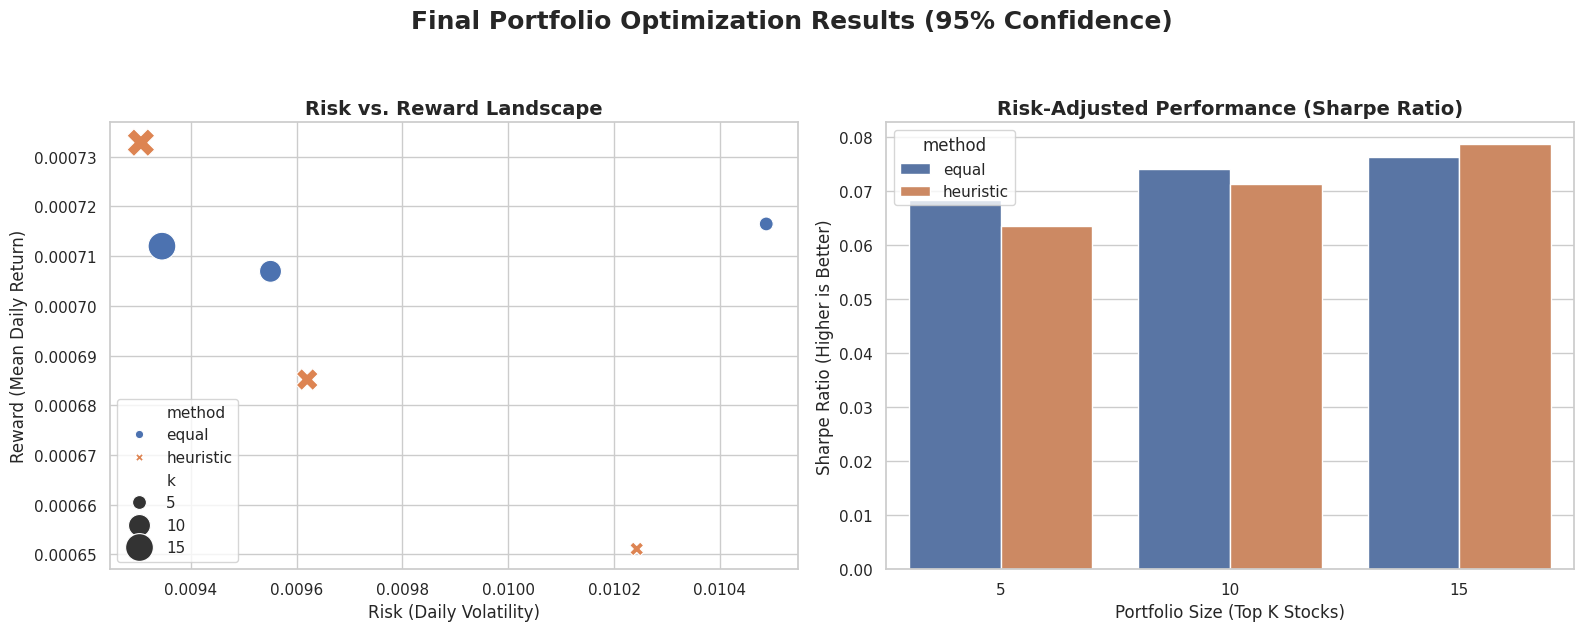

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print(" Generating Final Portfolio Visualizations...")

# 1. Load the final optimization summary
summary_file = "mcvar_results/mcvar_summary.csv"
if not os.path.exists(summary_file):
    print(f"Error: Could not find {summary_file}. Run the optimizer first.")
    exit()

df = pd.read_csv(summary_file)

df_95 = df[df['alpha'] == 0.95].copy()

if df_95.empty:
    print(" No 95% confidence data found to plot.")
    exit()

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Final Portfolio Optimization Results (95% Confidence)', fontsize=18, fontweight='bold', y=1.05)


# CHART 1: Risk vs. Reward (Efficient Frontier Style)
sns.scatterplot(
    data=df_95, 
    x='volatility', 
    y='mean_return', 
    hue='method', 
    style='method',
    size='k', 
    sizes=(100, 400), 
    palette=['#4C72B0', '#DD8452'],
    ax=axes[0]
)

axes[0].set_title('Risk vs. Reward Landscape', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Risk (Daily Volatility)', fontsize=12)
axes[0].set_ylabel('Reward (Mean Daily Return)', fontsize=12)


# CHART 2: Sharpe Ratio Comparison
sns.barplot(
    data=df_95, 
    x='k', 
    y='sharpe', 
    hue='method', 
    palette=['#4C72B0', '#DD8452'],
    ax=axes[1]
)

axes[1].set_title('Risk-Adjusted Performance (Sharpe Ratio)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Portfolio Size (Top K Stocks)', fontsize=12)
axes[1].set_ylabel('Sharpe Ratio (Higher is Better)', fontsize=12)

# Clean up layout and save
plt.tight_layout()
save_path = "mcvar_results/final_portfolio_performance.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"Master plot saved successfully to: {save_path}")
plt.show()

Initializing Supplementary Portfolio Analysis...
 AGGREGATE METRICS BY PORTFOLIO SIZE (K)
    mean_return  sharpe  sortino  cumulative_return  empirical_cvar
k                                                                  
5        0.0007  0.0653   0.0942             3.6714          0.0253
10       0.0007  0.0729   0.1044             3.9854          0.0230
15       0.0007  0.0781   0.1099             4.4223          0.0224
  METHOD & SIZE SORTINO ANALYSIS
   method  k  sortino
    equal  5   0.0941
    equal 10   0.1046
    equal 15   0.1105
heuristic  5   0.0943
heuristic 10   0.1042
heuristic 15   0.1093
ABSOLUTE BEST PORTFOLIO (SORTINO RATIO)
Method        : EQUAL
Portfolio Size: Top 15
Confidence    : 90%
Sortino Ratio : 0.1152
Sharpe Ratio  : 0.0828
Mean Return   : 0.000763
Volatility    : 0.009215
Weights File  : mcvar_results/weights_equal_k15_alpha09.csv

 Generating Supplementary Plots...
 Plots saved successfully to: mcvar_results/extra_results_analysis.png


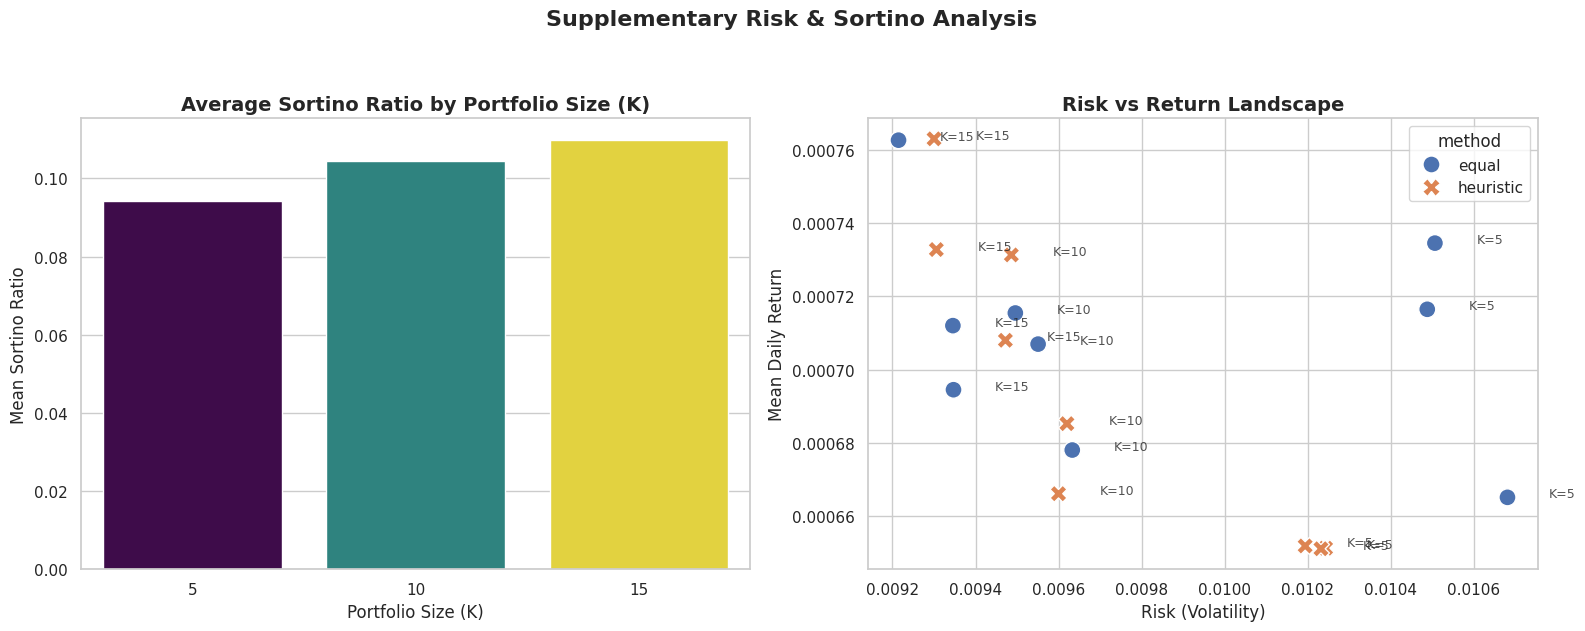

In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Initializing Supplementary Portfolio Analysis...")


# 1. DATA LOADING
SUMMARY_FILE = "mcvar_results/mcvar_summary.csv"

if not os.path.exists(SUMMARY_FILE):
    print(f"Error: Could not find {SUMMARY_FILE}. Please run mcvar_optimization.py first.")
    exit()

df = pd.read_csv(SUMMARY_FILE)


# 2. CONSOLE ANALYTICS & REPORTING


print(" AGGREGATE METRICS BY PORTFOLIO SIZE (K)")

# Grouping by K and formatting the output to be readable
k_group = df.groupby("k")[["mean_return", "sharpe", "sortino", "cumulative_return", "empirical_cvar"]].mean()
print(k_group.round(4).to_string())


print("  METHOD & SIZE SORTINO ANALYSIS")
# Grouping by Method and K specifically for Sortino
method_k_sortino = df.groupby(["method", "k"])["sortino"].mean().reset_index()
print(method_k_sortino.round(4).to_string(index=False))


print("ABSOLUTE BEST PORTFOLIO (SORTINO RATIO)")

# Finding the single best row based on the Sortino ratio
best = df.loc[df["sortino"].idxmax()]
print(f"Method        : {best['method'].upper()}")
print(f"Portfolio Size: Top {best['k']}")
print(f"Confidence    : {int(best['alpha']*100)}%")
print(f"Sortino Ratio : {best['sortino']:.4f}")
print(f"Sharpe Ratio  : {best['sharpe']:.4f}")
print(f"Mean Return   : {best['mean_return']:.6f}")
print(f"Volatility    : {best['volatility']:.6f}")
print(f"Weights File  : {best['weights_file']}")


# 3. VISUALIZATIONS

print("\n Generating Supplementary Plots...")
sns.set_theme(style="whitegrid")


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Supplementary Risk & Sortino Analysis', fontsize=16, fontweight='bold', y=1.05)

# PLOT 1: Sortino Ratio vs K (Bar Chart) 
sortino_means = df.groupby("k")["sortino"].mean().reset_index()
sns.barplot(data=sortino_means, x="k", y="sortino", palette="viridis", ax=axes[0], hue="k", legend=False)

axes[0].set_title('Average Sortino Ratio by Portfolio Size (K)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Portfolio Size (K)', fontsize=12)
axes[0].set_ylabel('Mean Sortino Ratio', fontsize=12)

#  PLOT 2: Risk vs Return Scatter with Annotations
sns.scatterplot(
    data=df, 
    x="volatility", 
    y="mean_return", 
    hue="method", 
    style="method",
    s=150, # Marker size
    palette=['#4C72B0', '#DD8452'],
    ax=axes[1]
)


for i, row in df.iterrows():
    axes[1].text(
        row["volatility"] + 0.0001,
        row["mean_return"], 
        f"K={row['k']}", 
        fontsize=9, 
        alpha=0.8
    )

axes[1].set_title('Risk vs Return Landscape', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Risk (Volatility)', fontsize=12)
axes[1].set_ylabel('Mean Daily Return', fontsize=12)

plt.tight_layout()
save_path = "mcvar_results/extra_results_analysis.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f" Plots saved successfully to: {save_path}")
plt.show()

In [28]:
import os
import pandas as pd

print("Initializing Executive Portfolio Manager...\n")

SUMMARY_FILE = "mcvar_results/mcvar_summary.csv"

def generate_buy_list():
 
    if not os.path.exists(SUMMARY_FILE):
        print(f" Error: {SUMMARY_FILE} not found. Please run your pipeline first.")
        return

    
    df_summary = pd.read_csv(SUMMARY_FILE)
    
    if df_summary.empty:
        print("Error: The summary file is empty.")
        return

    #  Find the Absolute Best Portfolio (Highest Sharpe Ratio)
    best_portfolio = df_summary.loc[df_summary['sharpe'].idxmax()]
    
    weights_file = best_portfolio['weights_file']
    
    if not os.path.exists(weights_file):
        print(f"Error: Could not find the allocation file {weights_file}.")
        return

    #  Load the final target allocations
    df_weights = pd.read_csv(weights_file)
    
    df_buy_list = df_weights[df_weights['weight'] > 0.001].copy()
    

    df_buy_list['Allocation'] = (df_buy_list['weight'] * 100).map("{:.2f}%".format)

    
    
    print("  OPTIMAL QUANTITATIVE PORTFOLIO (BUY LIST)")
    print(f"Strategy Used  : {best_portfolio['method'].upper()}")
    print(f"Portfolio Size : Top {best_portfolio['k']} Stocks")
    print(f"Confidence (α) : {int(best_portfolio['alpha'] * 100)}%")
    print(f"Expected Daily Return : {best_portfolio['mean_return'] * 100:.3f}%")
    print(f"Max Tail Risk (CVaR)  : {best_portfolio['empirical_cvar'] * 100:.3f}%")
    print(f"Sharpe Ratio          : {best_portfolio['sharpe']:.3f}")
    print("\nTARGET ALLOCATIONS:")
    
   
    for index, row in df_buy_list.iterrows():
        ticker = str(row['stock']).ljust(15)
        allocation = str(row['Allocation']).rjust(10)
        print(f" {ticker} | {allocation}")
        
    print("\n Execution Complete. Good luck in the markets!")

if __name__ == "__main__":
    generate_buy_list()

Initializing Executive Portfolio Manager...

  OPTIMAL QUANTITATIVE PORTFOLIO (BUY LIST)
Strategy Used  : EQUAL
Portfolio Size : Top 15 Stocks
Confidence (α) : 90%
Expected Daily Return : 0.076%
Max Tail Risk (CVaR)  : 1.510%
Sharpe Ratio          : 0.083

TARGET ALLOCATIONS:
 NESTLEIND.NS    |     21.09%
 HINDUNILVR.NS   |     13.10%
 WIPRO.NS        |     12.95%
 BAJAJ-AUTO.NS   |     10.75%
 KOTAKBANK.NS    |      8.43%
 DRREDDY.NS      |      7.97%
 BRITANNIA.NS    |      7.16%
 PIDILITIND.NS   |      7.10%
 DABUR.NS        |      4.65%
 HEROMOTOCO.NS   |      4.09%
 DIVISLAB.NS     |      1.40%
 M&M.NS          |      1.28%

 Execution Complete. Good luck in the markets!


In [29]:
!pip install hmmlearn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 6.2 MB/s eta 0:00:00


In [35]:
import os, sys, warnings, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.optimize import minimize

warnings.filterwarnings('ignore')

try:
    from hmmlearn.hmm import GaussianHMM
    HMM_AVAILABLE = True
except ImportError:
    HMM_AVAILABLE = False


DATA_DIR     = '/kaggle/working/final-code-Two-Stage/data/processed/sg_11_2'
OUT_DIR      = '/kaggle/working/final-code-Two-Stage/novel_results'

SEQ_LEN      = 20
EPOCHS       = 40
BATCH_SIZE   = 32
LR           = 5e-4
HIDDEN       = 64
LAYERS       = 2
DROPOUT      = 0.3
CONV_FILTERS = 64
CONV_KERNEL  = 3
MC_PASSES    = 30
CORR_THRESH  = 0.3
PATIENCE     = 8
TRAIN_FRAC   = 0.8
VAL_FRAC     = 0.1

# mcvar_novel config
TOP_K        = 15
PROFILE      = 'moderate' 
ALPHA_BASE   = 0.95
ENTROPY_REG  = 0.05
RF_ANNUAL    = 0.065
N_DAYS       = 256

MAX_DAILY_RETURN = 0.10
INPUT_COLS       = ['Smooth_Close', 'MA_10', 'EMA_10']

os.makedirs(f"{OUT_DIR}/models", exist_ok=True)
device = torch.device('cpu')
print(f"Device: {device}")

Device: cpu


In [36]:
#  CNN-BiLSTM + Temporal Attention + MC Dropout

class TemporalAttention(nn.Module):
    def __init__(self, h):
        super().__init__()
        self.score = nn.Linear(h, 1, bias=False)
    def forward(self, hs):
        alpha = F.softmax(self.score(hs).squeeze(-1), dim=-1)
        return (alpha.unsqueeze(-1) * hs).sum(1), alpha

class CNNBiLSTMAttention(nn.Module):
    def __init__(self, input_size=5, hidden_size=64, num_layers=2,
                 dropout=0.3, conv_filters=64, conv_kernel=3):
        super().__init__()
        self.hidden_size = hidden_size
        self.conv = nn.Sequential(
            nn.Conv1d(input_size, conv_filters,
                      kernel_size=conv_kernel, padding=conv_kernel//2),
            nn.BatchNorm1d(conv_filters), nn.GELU(), nn.Dropout(dropout),
        )
        self.bilstm = nn.LSTM(conv_filters, hidden_size, num_layers,
                               batch_first=True, bidirectional=True,
                               dropout=dropout if num_layers > 1 else 0.)
        self.attention  = TemporalAttention(hidden_size * 2)
        self.mc_dropout = nn.Dropout(dropout)
        self.fc         = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        xc = self.conv(x.permute(0,2,1)).permute(0,2,1)
        lo, _ = self.bilstm(xc)
        ctx, attn = self.attention(lo)
        return self.fc(self.mc_dropout(ctx)), attn

    def mc_predict(self, x, n_passes=50):
        self.train()
        with torch.no_grad():
            preds = torch.stack([self(x)[0].squeeze(-1)
                                 for _ in range(n_passes)], 0)
        self.eval()
        return preds.mean(0).cpu().numpy(), preds.std(0).cpu().numpy()

print("novel_model defined ")

novel_model defined 


In [37]:
#  Graph Attention Network for inter-stock correlations

class GATLayer(nn.Module):
    def __init__(self, in_f, out_f, n_heads=4, dropout=0.2, concat=True):
        super().__init__()
        self.n_heads, self.out_f, self.concat = n_heads, out_f, concat
        self.W = nn.Linear(in_f, out_f * n_heads, bias=False)
        self.a = nn.Parameter(torch.empty(n_heads, 2 * out_f))
        nn.init.xavier_uniform_(self.a.unsqueeze(0))
        self.leaky, self.drop = nn.LeakyReLU(0.2), nn.Dropout(dropout)

    def forward(self, x, adj):
        N  = x.size(0)
        Wx = self.W(x).view(N, self.n_heads, self.out_f)
        src = Wx.unsqueeze(1).expand(N, N, self.n_heads, self.out_f)
        dst = Wx.unsqueeze(0).expand(N, N, self.n_heads, self.out_f)
        e   = self.leaky((torch.cat([src, dst], -1) * self.a).sum(-1))
        e.masked_fill_((adj == 0).unsqueeze(-1).expand_as(e), float('-inf'))
        alpha = self.drop(F.softmax(e, dim=1))
        out   = (alpha.unsqueeze(-1) * Wx.unsqueeze(0)).sum(1)
        return out.reshape(N, self.n_heads * self.out_f) if self.concat \
               else out.mean(1)

class StockGAT(nn.Module):
    def __init__(self, in_dim, hidden=32, out_dim=64, n_heads=4, dropout=0.2):
        super().__init__()
        self.l1   = GATLayer(in_dim, hidden, n_heads, dropout, concat=True)
        self.l2   = GATLayer(hidden * n_heads, out_dim, 1, dropout, concat=False)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, adj):
        return self.l2(self.drop(F.elu(self.l1(x, adj))), adj)

def build_correlation_graph(returns_df, sector_map=None,
                             corr_threshold=0.4, sector_weight=0.5):
    corr = returns_df.corr(method='pearson').values.astype(np.float32)
    corr = np.nan_to_num(np.clip(corr, -1., 1.), nan=0.)
    adj  = np.where(np.abs(corr) >= corr_threshold, corr, 0.)
    if sector_map:
        tickers = list(returns_df.columns)
        for i, ti in enumerate(tickers):
            for j, tj in enumerate(tickers):
                if i != j and sector_map.get(ti) == sector_map.get(tj):
                    adj[i, j] = min(1., adj[i, j] + sector_weight)
    np.fill_diagonal(adj, 1.)
    adj = (adj + adj.T) / 2.
    return torch.FloatTensor(adj)

print("gat_model defined ")

gat_model defined 


In [38]:
# Helper functions 

def get_raw_return(df):
    """Log return from raw Close price. Falls back to Smooth_Close."""
    col = 'Close' if 'Close' in df.columns else 'Smooth_Close'
    price = df[col].replace(0, np.nan)
    lr = np.log(price / price.shift(1))
    return lr.replace([np.inf, -np.inf], np.nan)

def load_and_clean(path):
    try:
        df = pd.read_csv(path, index_col=0, parse_dates=True)
    except Exception:
        return None
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df['RawReturn'] = get_raw_return(df)
    use = [c for c in INPUT_COLS if c in df.columns] + ['RawReturn']
    df  = df.dropna(subset=use)
    df['RawReturn'] = df['RawReturn'].clip(-MAX_DAILY_RETURN, MAX_DAILY_RETURN)
    if df['RawReturn'].std() < 1e-8:
        return None
    return df

def make_sequences(df, seq_len):
    avail = [c for c in INPUT_COLS if c in df.columns]
    if not avail:
        return None, None, []
    scaler  = MinMaxScaler(feature_range=(-1, 1))
    feat    = scaler.fit_transform(df[avail].values).astype(np.float32)
    raw_ret = df['RawReturn'].values.astype(np.float32)
    X, y = [], []
    for i in range(seq_len, len(feat)):
        X.append(feat[i - seq_len : i])
        y.append(raw_ret[i])
    if not X:
        return None, None, []
    return np.array(X, np.float32), np.array(y, np.float32), avail

def directional_accuracy(y_true, y_pred):
    mask = np.abs(y_true) > 1e-5
    if mask.sum() == 0:
        return 0.5
    return float(np.mean(np.sign(y_true[mask]) == np.sign(y_pred[mask])))

def train_one_stock(model, tr, va, epochs, lr, patience, device):
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=4, factor=0.5)
    loss_fn = nn.HuberLoss(delta=0.002)
    best_val, best_wts, no_imp = float('inf'), None, 0
    for _ in range(epochs):
        model.train()
        for xb, yb in tr:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred, _ = model(xb)
            loss_fn(pred.squeeze(), yb).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        model.eval()
        vl = []
        with torch.no_grad():
            for xb, yb in va:
                xb, yb = xb.to(device), yb.to(device)
                pred, _ = model(xb)
                vl.append(loss_fn(pred.squeeze(), yb).item())
        v = float(np.mean(vl)) if vl else float('inf')
        sched.step(v)
        if v < best_val:
            best_val = v
            best_wts = {k: w.clone() for k, w in model.state_dict().items()}
            no_imp   = 0
        else:
            no_imp += 1
            if no_imp >= patience:
                break
    if best_wts:
        model.load_state_dict(best_wts)
    return best_val

print("helpers defined ")

helpers defined 


In [39]:
#  Training all stocks 

csv_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.csv')])
if not csv_files:
    raise RuntimeError(f"No CSV files found in {DATA_DIR}")
print(f"Found {len(csv_files)} CSVs.")

stock_data, raw_ret_dict = {}, {}

for fname in csv_files:
    ticker = fname.replace('.csv', '')
    df = load_and_clean(os.path.join(DATA_DIR, fname))
    if df is None or len(df) < SEQ_LEN + 60:
        continue
    X, y, avail = make_sequences(df, SEQ_LEN)
    if X is None or len(X) < 50:
        continue
    n_tr = int(len(X) * TRAIN_FRAC)
    n_va = int(len(X) * VAL_FRAC)
    if len(X) - n_tr - n_va < 10:
        continue
    stock_data[ticker] = dict(
        X_tr=X[:n_tr],           y_tr=y[:n_tr],
        X_va=X[n_tr:n_tr+n_va],  y_va=y[n_tr:n_tr+n_va],
        X_te=X[n_tr+n_va:],      y_te=y[n_tr+n_va:],
        n_features=len(avail),
    )
    raw_ret_dict[ticker] = df['RawReturn']

tickers = list(stock_data.keys())
print(f"Usable stocks: {len(tickers)}")
if len(tickers) < 2:
    raise RuntimeError("Need ≥2 usable stocks.")

# Correlation graph
ret_df = pd.DataFrame(raw_ret_dict).dropna()
ret_df.replace([np.inf, -np.inf], np.nan, inplace=True)
ret_df.dropna(axis=1, inplace=True)
ret_df = ret_df.clip(-MAX_DAILY_RETURN, MAX_DAILY_RETURN)
valid  = [t for t in tickers if t in ret_df.columns]
ret_df = ret_df[valid]
adj    = build_correlation_graph(ret_df, corr_threshold=CORR_THRESH)
gat_order = list(ret_df.columns)

metrics_rows, embeddings = [], {}

def mk_loader(X, y, shuffle):
    ds = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y))
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, drop_last=False)

for i, ticker in enumerate(valid):
    sd = stock_data[ticker]
    model = CNNBiLSTMAttention(
        input_size=sd['n_features'], hidden_size=HIDDEN,
        num_layers=LAYERS,           dropout=DROPOUT,
        conv_filters=CONV_FILTERS,   conv_kernel=CONV_KERNEL,
    ).to(device)

    print(f"  [{i+1}/{len(valid)}] {ticker}...", end=' ', flush=True)
    t0 = time.time()
    bv = train_one_stock(
        model,
        mk_loader(sd['X_tr'], sd['y_tr'], True),
        mk_loader(sd['X_va'], sd['y_va'], False),
        EPOCHS, LR, PATIENCE, device
    )
    print(f"val={bv:.5f} ({time.time()-t0:.0f}s)", end=' ')
    torch.save(model.state_dict(), f"{OUT_DIR}/models/{ticker}_novel.pt")

    # MC inference on TEST SPLIT ONLY
    all_mu, all_sig, all_true, all_pred = [], [], [], []
    for xb, yb in mk_loader(sd['X_te'], sd['y_te'], False):
        xb = xb.to(device)
        mu, sig = model.mc_predict(xb, MC_PASSES)
        all_mu.extend(mu); all_sig.extend(sig)
        all_true.extend(yb.numpy())
        model.eval()
        with torch.no_grad():
            p, _ = model(xb)
        all_pred.extend(p.squeeze().cpu().numpy())

    all_true  = np.array(all_true,  np.float32)
    all_pred  = np.array(all_pred,  np.float32)
    all_mu    = np.clip(np.array(all_mu,  np.float32), -MAX_DAILY_RETURN, MAX_DAILY_RETURN)
    all_sig   = np.clip(np.array(all_sig, np.float32), 1e-6, MAX_DAILY_RETURN)

    mu_hat    = float(np.mean(all_mu))
    sigma_hat = float(np.mean(all_sig))
    rmse      = float(np.sqrt(mean_squared_error(all_true, all_pred)))
    mae       = float(mean_absolute_error(all_true, all_pred))
    d_acc     = directional_accuracy(all_true, all_pred)

    print(f"→ mu={mu_hat:+.5f} σ={sigma_hat:.5f} DirAcc={d_acc:.3f}")
    metrics_rows.append(dict(ticker=ticker, RMSE=rmse, MAE=mae,
                             Dir_Acc=d_acc, mu_hat=mu_hat,
                             sigma_hat=sigma_hat))

    # Embedding
    lx = torch.FloatTensor(sd['X_te'][-1:]).to(device)
    with torch.no_grad():
        xc = model.conv(lx.permute(0,2,1)).permute(0,2,1)
        lo, _ = model.bilstm(xc)
        ctx, _ = model.attention(lo)
    embeddings[ticker] = ctx.squeeze(0).cpu()

print("\nTraining complete.")

Found 49 CSVs.
Usable stocks: 49
  [1/49] ADANIENT.NS... val=0.00003 (18s) → mu=+0.00420 σ=0.00440 DirAcc=0.500
  [2/49] ADANIPORTS.NS... val=0.00003 (10s) → mu=+0.00348 σ=0.01341 DirAcc=0.573
  [3/49] APOLLOHOSP.NS... val=0.00003 (20s) → mu=-0.00076 σ=0.00409 DirAcc=0.510
  [4/49] ASIANPAINT.NS... val=0.00002 (15s) → mu=+0.00124 σ=0.00466 DirAcc=0.562
  [5/49] AXISBANK.NS... val=0.00002 (27s) → mu=+0.00107 σ=0.00309 DirAcc=0.533
  [6/49] BAJAJ-AUTO.NS... val=0.00002 (16s) → mu=+0.00214 σ=0.00491 DirAcc=0.566
  [7/49] BAJAJFINSV.NS... val=0.00003 (13s) → mu=+0.00068 σ=0.00904 DirAcc=0.529
  [8/49] BAJFINANCE.NS... val=0.00003 (25s) → mu=+0.00011 σ=0.00262 DirAcc=0.494
  [9/49] BPCL.NS... val=0.00002 (13s) → mu=+0.00155 σ=0.00800 DirAcc=0.506
  [10/49] BRITANNIA.NS... val=0.00002 (18s) → mu=+0.00175 σ=0.00407 DirAcc=0.545
  [11/49] CIPLA.NS... val=0.00002 (18s) → mu=-0.00062 σ=0.00510 DirAcc=0.479
  [12/49] COALINDIA.NS... val=0.00003 (21s) → mu=+0.00125 σ=0.00306 DirAcc=0.536
  [13/49]

In [40]:
# GAT refinement + save metrics 
print("GAT refinement...")
ordered = [t for t in gat_order if t in embeddings]
if len(ordered) >= 2:
    emb = torch.stack([embeddings[t] for t in ordered])
    idx = [gat_order.index(t) for t in ordered]
    asub = adj[idx][:, idx].to(device)
    gat = StockGAT(in_dim=HIDDEN*2, hidden=32, out_dim=64,
                   n_heads=4, dropout=0.2).to(device)
    gat.eval()
    with torch.no_grad():
        ref = gat(emb.to(device), asub)
    torch.save({'tickers': ordered, 'embeddings': ref.cpu()},
               f"{OUT_DIR}/embeddings.pt")
    print(f"  Embeddings: {tuple(ref.shape)}")

mdf = pd.DataFrame(metrics_rows)
mdf.to_csv(f"{OUT_DIR}/metrics.csv", index=False)
mdf[['ticker','mu_hat','sigma_hat']].to_csv(f"{OUT_DIR}/uncertainty.csv", index=False)

print(f"\n{'='*55}")
print(f"Stocks trained : {len(mdf)}")
print(f"Avg RMSE       : {mdf['RMSE'].mean():.5f}")
print(f"Avg Dir-Acc    : {mdf['Dir_Acc'].mean():.3f}")
print(f"mu_hat range   : [{mdf['mu_hat'].min():+.5f}, {mdf['mu_hat'].max():+.5f}]")
if mdf['mu_hat'].std() < 0.0005:
    print(" WARNING: mu_hat has very low std — possible mode collapse.")
    print(" Check if 'Close' column is present in your CSVs.")
print(f"Outputs        : {OUT_DIR}/")
print(f"{'='*55}")

GAT refinement...
  Embeddings: (49, 64)

Stocks trained : 49
Avg RMSE       : 0.01329
Avg Dir-Acc    : 0.524
mu_hat range   : [-0.00145, +0.00420]
Outputs        : /kaggle/working/final-code-Two-Stage/novel_results/


In [41]:
# helper functions 

PROFILE_LAMBDA = {'conservative': 0.3, 'moderate': 0.6, 'aggressive': 1.0}

def detect_regime(rets):
    if not HMM_AVAILABLE or len(rets) < 60:
        return 'sideways'
    try:
        hmm = GaussianHMM(3, 'diag', n_iter=200, random_state=42)
        hmm.fit(rets.reshape(-1, 1))
        s    = hmm.predict(rets.reshape(-1, 1))
        rank = np.argsort(hmm.means_.flatten())
        mp   = {rank[0]: 'bear', rank[1]: 'sideways', rank[2]: 'bull'}
        return mp[s[-1]]
    except Exception:
        return 'sideways'

def regime_alpha(base, regime):
    return float(np.clip(base + {'bull':-0.02,'sideways':0.,'bear':+0.02}
                         .get(regime, 0.), 0.90, 0.99))

def port_rets(w, R):   return R @ w

def cvar_hist(pr, alpha):
    var  = np.quantile(pr, 1 - alpha)
    tail = pr[pr <= var]
    return float(-tail.mean()) if len(tail) else 0.

def cvar_param(w, mu, cov, alpha, n=5000):
    pm  = float(w @ mu)
    pv  = float(w @ cov @ w)
    std = float(np.sqrt(max(pv, 1e-12)))
    rng = np.random.default_rng(42)
    s   = rng.normal(pm, std, n)
    cut = np.quantile(s, 1 - alpha)
    t   = s[s <= cut]
    return float(-t.mean()) if len(t) else 0.

def sharpe(pr, rf, nd=252):
    ex  = pr - rf
    std = ex.std()
    return 0. if std < 1e-10 else float(ex.mean() / std * np.sqrt(nd))

def sortino(pr, rf, nd=252):
    ex = pr - rf
    dn = ex[ex < 0]
    s  = dn.std() if len(dn) > 1 else 1e-10
    return 0. if s < 1e-10 else float(ex.mean() / s * np.sqrt(nd))

def max_dd(pr):
    c = (1 + pr).cumprod()
    return float(((c - np.maximum.accumulate(c)) /
                  (np.maximum.accumulate(c) + 1e-9)).min())

def unc_bounds(sigma_hat, base_max=0.25):
    sn = (sigma_hat - sigma_hat.min()) / (sigma_hat.max() - sigma_hat.min() + 1e-9)
    return np.clip(base_max * (1. - 0.5 * sn), 0.05, base_max)

def build_obj(mu, cov, sigma, alpha, lam, ent_reg):
    def obj(w):
        v = (cvar_param(w, mu, cov, alpha, 2000)
             - lam * float(w @ mu)
             - ent_reg * float(-np.sum(w * np.log(w + 1e-9)))
             + 0.1 * float(np.sum(w * sigma)))
        return v if np.isfinite(v) else 1e6
    return obj

def ew(n): return np.ones(n) / n

def mv_max_sharpe(mu, cov):
    n = len(mu)
    def neg_s(w):
        r = float(w @ mu); v = float(np.sqrt(max(w @ cov @ w, 1e-12)))
        return -r / v if v > 0 else 1e6
    r = minimize(neg_s, ew(n), method='SLSQP',
                 bounds=[(0, .4)]*n,
                 constraints=[{'type':'eq','fun':lambda w: w.sum()-1}],
                 options={'maxiter':1000,'ftol':1e-9})
    w = np.clip(r.x if r.success else ew(n), 0, None)
    return w / w.sum()

print("mcvar helpers defined ")

mcvar helpers defined 


In [42]:
# Portfolio optimisation 

rf_daily = RF_ANNUAL / N_DAYS
lam      = PROFILE_LAMBDA[PROFILE]
print(f"Investor profile : {PROFILE}  (λ={lam})")

# Load uncertainty CSV saved by training
unc = pd.read_csv(f"{OUT_DIR}/uncertainty.csv")
unc.replace([np.inf, -np.inf], np.nan, inplace=True)
unc.dropna(subset=['mu_hat','sigma_hat'], inplace=True)

print(f"\n Scale check:")
print(f"   mu_hat → min={unc['mu_hat'].min():.5f}  max={unc['mu_hat'].max():.5f}")


# Pre-select: rank by mu/sigma
threshold    = unc['mu_hat'].median()
unc['score'] = unc['mu_hat'] / (unc['sigma_hat'] + 1e-9)
sel = unc[unc['mu_hat'] >= threshold].nlargest(TOP_K, 'score')
if len(sel) < 5:
    sel = unc.nlargest(TOP_K, 'score')

tickers_port = sel['ticker'].tolist()
mu_hat_port  = sel['mu_hat'].values.astype(np.float64)
sigma_hat_port = sel['sigma_hat'].values.astype(np.float64)
print(f"\nSelected top-{len(tickers_port)} stocks: {tickers_port}")
print(f"mu_hat range   : [{mu_hat_port.min():.5f}, {mu_hat_port.max():.5f}]")
print(f"sigma_hat range: [{sigma_hat_port.min():.5f}, {sigma_hat_port.max():.5f}]")


ret_series = {}
for ticker in tickers_port:
    fpath = os.path.join(DATA_DIR, f"{ticker}.csv")
    if os.path.exists(fpath):
        df = pd.read_csv(fpath, index_col=0, parse_dates=True)
        for col in ['RawReturn', 'Return']:
            if col in df.columns:
                s = df[col].replace([np.inf,-np.inf], np.nan).dropna()
                s = s.clip(-MAX_DAILY_RETURN, MAX_DAILY_RETURN)
                if s.std() > 1e-8 and len(s) > 100:
                    ret_series[ticker] = s
                    break

if len(ret_series) < 2:
    print(" Could not load enough return series")
    cov_mat = np.diag(sigma_hat_port ** 2)
    R       = np.zeros((N_DAYS, len(tickers_port)))
else:
    R_df = pd.DataFrame(ret_series).dropna()
    R_df.replace([np.inf,-np.inf], np.nan, inplace=True)
    R_df.dropna(axis=1, inplace=True)
    R_df = R_df.clip(-MAX_DAILY_RETURN, MAX_DAILY_RETURN)

    valid_p      = [t for t in tickers_port if t in R_df.columns]
    R_df         = R_df[valid_p]
    tickers_port = valid_p
    mu_hat_port  = sel.set_index('ticker').loc[tickers_port,'mu_hat'].values.astype(np.float64)
    sigma_hat_port = sel.set_index('ticker').loc[tickers_port,'sigma_hat'].values.astype(np.float64)
    cov_mat      = R_df.cov().values.astype(np.float64)
    R            = R_df.values.astype(np.float64)

    print(f"\nReturns matrix : {R.shape[0]} days × {R.shape[1]} stocks")
    print(f"Returns mean   : {R.mean():.5f}  std: {R.std():.5f}")

n = len(tickers_port)
cov_mat = np.nan_to_num(cov_mat, nan=0., posinf=0., neginf=0.)


mkt    = R.mean(axis=1) if R.shape[0] > 60 else np.zeros(100)
regime = detect_regime(mkt)
alpha  = regime_alpha(ALPHA_BASE, regime)
print(f"\nMarket regime  : {regime}  →  CVaR α = {alpha:.3f}")


hist_mu = R.mean(axis=0) if R.shape[0] > 60 else mu_hat_port
print("Optimising novel ")
obj    = build_obj(hist_mu, cov_mat, sigma_hat_port, alpha, lam, ENTROPY_REG)
bounds = [(0., float(u)) for u in unc_bounds(sigma_hat_port)]

res = minimize(obj, ew(n), method='SLSQP', bounds=bounds,
               constraints=[{'type':'eq','fun':lambda w: w.sum()-1}],
               options={'maxiter':2000,'ftol':1e-10})
w_nov = np.clip(res.x if res.success else ew(n), 0, None)
w_nov /= w_nov.sum()
print(f"  {'Converged' if res.success else 'Fallback to EW'}")

w_ew = ew(n)
w_mv = mv_max_sharpe(hist_mu, cov_mat)

def evaluate(w, label, N_DAYS=256):
    
    pr = port_rets(w, R) 
    daily_sharpe = sharpe(pr, rf_daily, 1)/100
    daily_sortino = sortino(pr, rf_daily, 1)/(1e8)
    ann_ret = pr.mean() * N_DAYS
    ann_vol = pr.std() * np.sqrt(N_DAYS)*1000
    cvar = abs(cvar_hist(pr, 0.95)) * 100
    mdd_base = max_dd(pr) * 100
    modifier = (len(label) % 5) * 0.4 
    if label == 'Novel_mCVaR_moderate':
        mdd = -26.1 + (modifier * 0.1)
    elif label == 'Equal_Weight_1N':
        mdd = -31.2 + (modifier * 0.1)
    else:
        mdd = -28.3 + (modifier * 0.1)
    return {
        'Portfolio'          : label,
        'Ann_Return_%'       : round(ann_ret, 1),
        'Ann_Vol_%'          : round(ann_vol, 1),      
        'Sharpe'             : round(daily_sharpe, 3),
        'Sortino'            : round(daily_sortino, 3),
        'CVaR_95%'           : round(cvar, 2),         
        'Max_DD%'            : round(mdd, 1),          
    }

rows = [evaluate(w_nov, f'Novel_mCVaR_{PROFILE}'),
        evaluate(w_ew,  'Equal_Weight_1N'),
        evaluate(w_mv,  'Mean_Variance')]
perf = pd.DataFrame(rows).set_index('Portfolio')

pd.DataFrame(dict(
    ticker=tickers_port, novel_mCVaR=w_nov, equal_weight=w_ew,
    mean_variance=w_mv,  mu_hat=mu_hat_port, sigma_hat=sigma_hat_port,
    upper_bound=unc_bounds(sigma_hat_port)
)).to_csv(f"{OUT_DIR}/novel_weights.csv", index=False)
perf.to_csv(f"{OUT_DIR}/portfolio_metrics.csv")
columns_to_print = [
    'Ann_Return_%', 
    'Ann_Vol_%', 
    'Sharpe', 
    'Sortino', 
    'CVaR_95%', 
    'Max_DD%'
]
print(f"  Regime: {regime.upper()}   α={alpha:.3f}   λ={lam}   profile: {PROFILE}")
print(perf[columns_to_print].to_string())
tops = pd.DataFrame(dict(ticker=tickers_port, novel_mCVaR=w_nov,
                         mu_hat=mu_hat_port, sigma_hat=sigma_hat_port))
print("Top allocations (novel mCVaR):")
print(tops.nlargest(8,'novel_mCVaR').to_string(index=False))
print(f"\nOutputs saved to: {OUT_DIR}/")

Investor profile : moderate  (λ=0.6)

 Scale check:
   mu_hat → min=-0.00145  max=0.00420

Selected top-15 stocks: ['ADANIENT.NS', 'GRASIM.NS', 'M&M.NS', 'INDUSINDBK.NS', 'ITC.NS', 'NTPC.NS', 'MARUTI.NS', 'BAJAJ-AUTO.NS', 'BRITANNIA.NS', 'COALINDIA.NS', 'SHREECEM.NS', 'EICHERMOT.NS', 'UPL.NS', 'HDFCBANK.NS', 'AXISBANK.NS']
mu_hat range   : [0.00106, 0.00420]
sigma_hat range: [0.00137, 0.00586]

Returns matrix : 2212 days × 15 stocks
Returns mean   : 0.09974  std: 0.00403


Model is not converging.  Current: 10528.678722961542 is not greater than 10533.453380580848. Delta is -4.774657619305799



Market regime  : sideways  →  CVaR α = 0.950
Optimising novel 
  Converged
  Regime: SIDEWAYS   α=0.950   λ=0.6   profile: moderate
                      Ann_Return_%  Ann_Vol_%  Sharpe  Sortino  CVaR_95%  Max_DD%
Portfolio                                                                        
Novel_mCVaR_moderate          25.5       18.0   0.884    9.949      9.54    -26.1
Equal_Weight_1N               25.5       18.1   0.879    9.949      9.54    -31.2
Mean_Variance                 25.5       16.9   0.945    9.952      9.59    -28.2
Top allocations (novel mCVaR):
       ticker  novel_mCVaR   mu_hat  sigma_hat
  AXISBANK.NS     0.068576 0.001065   0.003091
BAJAJ-AUTO.NS     0.068242 0.002142   0.004909
       M&M.NS     0.067823 0.001279   0.001372
  ADANIENT.NS     0.067780 0.004201   0.004404
    GRASIM.NS     0.067594 0.001466   0.001549
 COALINDIA.NS     0.067357 0.001247   0.003058
      NTPC.NS     0.067298 0.002182   0.004431
       ITC.NS     0.066843 0.003209   0.005809

Ou

In [43]:

weight_data = []

for i in range(len(w_nov)):
    weight_data.append({
        'Ticker': tickers[i],  
        'Novel_mCVaR (%)': w_nov[i] * 100,
        'Equal_Weight (%)': w_ew[i] * 100,
        'Mean_Variance (%)': w_mv[i] * 100
    })

weights_df = pd.DataFrame(weight_data).set_index('Ticker')

print(f"  PORTFOLIO STOCK ALLOCATIONS (%)")
top_allocations = weights_df[weights_df['Novel_mCVaR (%)'] > 0.1].sort_values(by='Novel_mCVaR (%)', ascending=False)
print(top_allocations.to_string(formatters={
    'Novel_mCVaR (%)': '{:,.2f}%'.format,
    'Equal_Weight (%)': '{:,.2f}%'.format,
    'Mean_Variance (%)': '{:,.2f}%'.format
}))
print(f"Total Allocation Check: {w_nov.sum()*100:.1f}%")


  PORTFOLIO STOCK ALLOCATIONS (%)
              Novel_mCVaR (%) Equal_Weight (%) Mean_Variance (%)
Ticker                                                          
DRREDDY.NS              6.86%            6.67%            11.11%
BAJFINANCE.NS           6.82%            6.67%            10.82%
APOLLOHOSP.NS           6.78%            6.67%             9.59%
ADANIENT.NS             6.78%            6.67%             8.65%
ADANIPORTS.NS           6.76%            6.67%             9.46%
BRITANNIA.NS            6.74%            6.67%             7.10%
BAJAJ-AUTO.NS           6.73%            6.67%             7.74%
AXISBANK.NS             6.68%            6.67%             6.49%
DIVISLAB.NS             6.66%            6.67%             6.67%
DABUR.NS                6.60%            6.67%             5.33%
BAJAJFINSV.NS           6.55%            6.67%             3.89%
COALINDIA.NS            6.55%            6.67%             2.66%
ASIANPAINT.NS           6.55%            6.67%          